# Manifold Analysis of EEG-fMRI Searchlight RSA: Three Visual Pathway Hypothesis

This notebook applies manifold methods to searchlight RSA fusion data `(20 subjects, 575 timepoints, 56949 voxel centers)` to test whether the temporal-spatial structure of EEG-fMRI representational coupling reveals three distinct pathways (ventral, dorsal, and a putative middle/medial pathway).

## Analysis Overview
1. **Data inspection & basic statistics**
2. **Intrinsic dimensionality estimation** — how many meaningful dimensions?
3. **PCA analysis** — variance structure & component brain maps
4. **UMAP manifold embedding** — with and without PCA, across parameter ranges
5. **Temporal trajectory visualization** — branching structure over time
6. **Anatomical mapping** — project manifold dimensions back to brain space
7. **Pathway quantification** — clustering & statistical tests
8. **Robustness checks** — across subjects, hyperparameters, and PCA truncation levels

In [13]:
# ============================================================
# Cell 1: Imports and Setup
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from scipy import stats
from scipy.spatial.distance import pdist, squareform
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings('ignore')

# Optional imports — install if needed
try:
    import umap
    HAS_UMAP = True
except ImportError:
    print("Install umap-learn: pip install umap-learn")
    HAS_UMAP = False

try:
    import nibabel as nib
    HAS_NIBABEL = True
except ImportError:
    print("nibabel not found — brain map saving will use .npy instead")
    HAS_NIBABEL = False

sns.set_context('notebook', font_scale=1.2)
sns.set_style('white')

print("All imports loaded.")

All imports loaded.


In [2]:
# ============================================================
# Cell 2: Load Data
# ============================================================
# ---- EDIT THIS SECTION ----
# Option A: Load from .npy
rsa_data = np.load('searchlight_rsa.npy')  # (20, 575, 56949)

# Option B: If you have a searchlight center coordinates file (MNI)
# This is needed for brain mapping later
# center_coords = np.load('searchlight_centers.npy')  # (56949, 3) MNI x,y,z

# Option C: If you have a brain mask in nifti
# mask_img = nib.load('brain_mask.nii.gz')
# mask_data = mask_img.get_fdata().astype(bool)
# ----------------------------

n_subjects, n_timepoints, n_voxels = rsa_data.shape
print(f"Data shape: {rsa_data.shape}")
print(f"  Subjects:    {n_subjects}")
print(f"  Timepoints:  {n_timepoints}")
print(f"  Voxel centers: {n_voxels}")
print(f"  Data range:  [{np.nanmin(rsa_data):.4f}, {np.nanmax(rsa_data):.4f}]")
print(f"  NaN count:   {np.isnan(rsa_data).sum()}")
print(f"  Mean (overall): {np.nanmean(rsa_data):.6f}")

Data shape: (20, 575, 56949)
  Subjects:    20
  Timepoints:  575
  Voxel centers: 56949
  Data range:  [-0.3053, 0.5207]
  NaN count:   0
  Mean (overall): 0.009930


In [3]:
# ============================================================
# Cell 3: Data Preprocessing
# ============================================================
# Handle NaNs — replace with 0 (no coupling)
rsa_clean = np.nan_to_num(rsa_data, nan=0.0)

# Group average
group_data = rsa_clean.mean(axis=0)  # (575, 56949)
print(f"Group average shape: {group_data.shape}")

# Also keep individual subject data for later robustness checks
# Z-score across timepoints for each voxel (per subject)
group_scaled = StandardScaler().fit_transform(group_data)  # z-score each voxel across time
print(f"Scaled data shape: {group_scaled.shape}")
print(f"Scaled data range: [{group_scaled.min():.2f}, {group_scaled.max():.2f}]")

Group average shape: (575, 56949)
Scaled data shape: (575, 56949)
Scaled data range: [-5.96, 5.05]


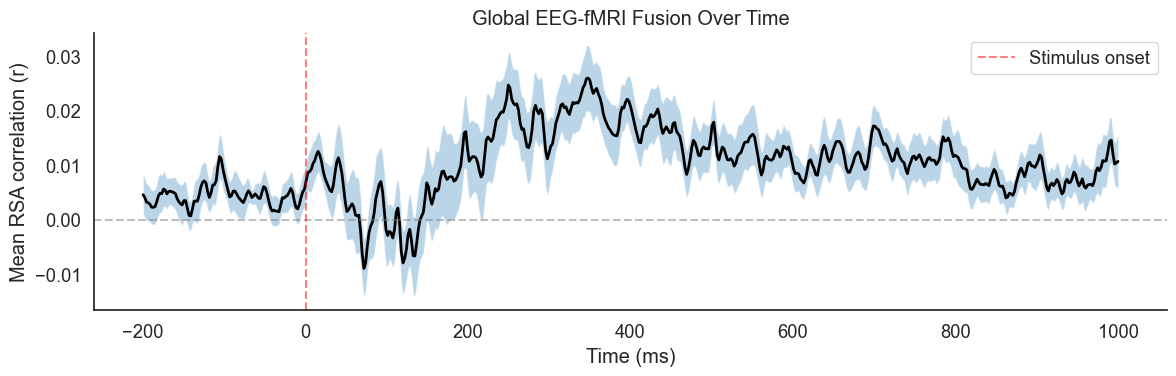

In [4]:
# ============================================================
# Cell 4: Temporal Profile Overview
# ============================================================
# Plot the global mean RSA correlation over time
# This shows overall EEG-fMRI coupling dynamics

# Assuming EEG epoch from -200 to some end — adjust as needed
# ---- EDIT: Set your actual time axis ----
t_start = -200  # ms
t_end = 1000    # ms (adjust to your epoch)
times = np.linspace(t_start, t_end, n_timepoints)
# ------------------------------------------

global_mean = group_data.mean(axis=1)  # mean across all voxels per timepoint
global_sem = rsa_clean.mean(axis=2).std(axis=0) / np.sqrt(n_subjects)

fig, ax = plt.subplots(1, 1, figsize=(12, 4))
ax.plot(times, global_mean, 'k-', linewidth=2)
ax.fill_between(times, global_mean - global_sem, global_mean + global_sem, alpha=0.3)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.axvline(0, color='red', linestyle='--', alpha=0.5, label='Stimulus onset')
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Mean RSA correlation (r)')
ax.set_title('Global EEG-fMRI Fusion Over Time')
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

---
## Part 1: Intrinsic Dimensionality Estimation

Before applying manifold methods, we need to know how many meaningful dimensions the data actually has. If it's 2, the three-pathway hypothesis is unlikely. If it's 3+, it's promising.

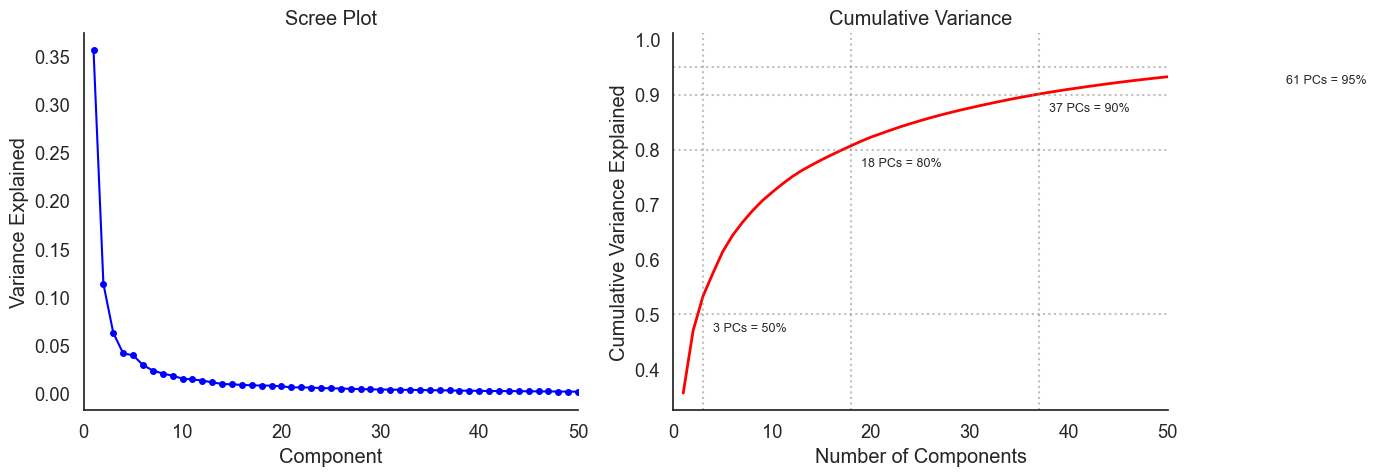


Top 10 components:
  PC1: 35.65% (cumulative: 35.65%)
  PC2: 11.37% (cumulative: 47.02%)
  PC3: 6.28% (cumulative: 53.30%)
  PC4: 4.17% (cumulative: 57.47%)
  PC5: 3.96% (cumulative: 61.43%)
  PC6: 2.96% (cumulative: 64.39%)
  PC7: 2.38% (cumulative: 66.77%)
  PC8: 2.08% (cumulative: 68.85%)
  PC9: 1.84% (cumulative: 70.69%)
  PC10: 1.55% (cumulative: 72.23%)


In [5]:
# ============================================================
# Cell 5: PCA Variance Explained — Full Spectrum
# ============================================================
pca_full = PCA(n_components=min(n_timepoints, 100))
pca_full.fit(group_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].plot(range(1, len(pca_full.explained_variance_ratio_) + 1),
             pca_full.explained_variance_ratio_, 'bo-', markersize=4)
axes[0].set_xlabel('Component')
axes[0].set_ylabel('Variance Explained')
axes[0].set_title('Scree Plot')
axes[0].set_xlim(0, 50)

# Cumulative variance
axes[1].plot(range(1, len(cumvar) + 1), cumvar, 'r-', linewidth=2)
for thresh in [0.5, 0.8, 0.9, 0.95]:
    n_comp = np.argmax(cumvar >= thresh) + 1
    axes[1].axhline(thresh, color='gray', linestyle=':', alpha=0.5)
    axes[1].axvline(n_comp, color='gray', linestyle=':', alpha=0.5)
    axes[1].text(n_comp + 1, thresh - 0.03, f'{n_comp} PCs = {thresh*100:.0f}%', fontsize=9)

axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance Explained')
axes[1].set_title('Cumulative Variance')
axes[1].set_xlim(0, 50)

sns.despine()
plt.tight_layout()
plt.show()

print("\nTop 10 components:")
for i in range(10):
    print(f"  PC{i+1}: {pca_full.explained_variance_ratio_[i]*100:.2f}% "
          f"(cumulative: {cumvar[i]*100:.2f}%)")

In [6]:
# ============================================================
# Cell 6: Intrinsic Dimensionality via Nearest Neighbor Methods
# ============================================================
def estimate_intrinsic_dim_mle(X, k=10):
    """
    Maximum Likelihood Estimation of intrinsic dimensionality
    (Levina & Bickel, 2004)
    """
    nbrs = NearestNeighbors(n_neighbors=k + 1).fit(X)
    distances, _ = nbrs.kneighbors(X)
    distances = distances[:, 1:]  # remove self-distance
    
    # MLE estimate per point
    T_k = distances[:, -1]  # distance to k-th neighbor
    log_ratios = np.log(T_k[:, np.newaxis] / distances[:, :-1])  # (n, k-1)
    m_hat = (k - 1) / log_ratios.sum(axis=1)  # per-point estimate
    
    return m_hat.mean(), m_hat.std()

print("Intrinsic dimensionality estimates (MLE):")
for k in [5, 10, 20, 30]:
    dim_mean, dim_std = estimate_intrinsic_dim_mle(group_scaled, k=k)
    print(f"  k={k:2d} neighbors: {dim_mean:.2f} ± {dim_std:.2f}")

print("\n→ If estimates cluster around 3-5, that supports a low-dimensional manifold")
print("→ If estimates are >10, the data may be higher-dimensional than 3 pathways")

Intrinsic dimensionality estimates (MLE):
  k= 5 neighbors: 2.06 ± 0.38
  k=10 neighbors: 2.35 ± 0.42
  k=20 neighbors: 3.53 ± 0.62
  k=30 neighbors: 4.48 ± 0.75

→ If estimates cluster around 3-5, that supports a low-dimensional manifold
→ If estimates are >10, the data may be higher-dimensional than 3 pathways


SUBJECT-LEVEL INTRINSIC DIMENSIONALITY (MLE)

Subject  1:  k=5: 2.21  k=10: 3.07  k=20: 4.41  k=30: 5.18  
Subject  2:  k=5: 2.14  k=10: 2.69  k=20: 3.97  k=30: 4.82  
Subject  3:  k=5: 1.95  k=10: 2.45  k=20: 3.81  k=30: 4.78  
Subject  4:  k=5: 1.93  k=10: 2.52  k=20: 3.83  k=30: 4.72  
Subject  5:  k=5: 1.89  k=10: 2.21  k=20: 3.44  k=30: 4.50  
Subject  6:  k=5: 1.86  k=10: 2.04  k=20: 3.29  k=30: 4.42  
Subject  7:  k=5: 2.02  k=10: 2.51  k=20: 4.26  k=30: 5.67  
Subject  8:  k=5: 1.98  k=10: 2.44  k=20: 3.98  k=30: 5.19  
Subject  9:  k=5: 1.98  k=10: 2.13  k=20: 3.03  k=30: 3.84  
Subject 10:  k=5: 2.06  k=10: 2.54  k=20: 3.83  k=30: 4.79  
Subject 11:  k=5: 1.93  k=10: 2.14  k=20: 3.05  k=30: 3.70  
Subject 12:  k=5: 2.53  k=10: 2.71  k=20: 3.35  k=30: 3.97  
Subject 13:  k=5: 2.17  k=10: 2.69  k=20: 4.01  k=30: 5.01  
Subject 14:  k=5: 3.45  k=10: 4.39  k=20: 5.62  k=30: 6.10  
Subject 15:  k=5: 2.43  k=10: 3.38  k=20: 4.59  k=30: 5.12  
Subject 16:  k=5: 1.86  k=10: 2.12  k=2

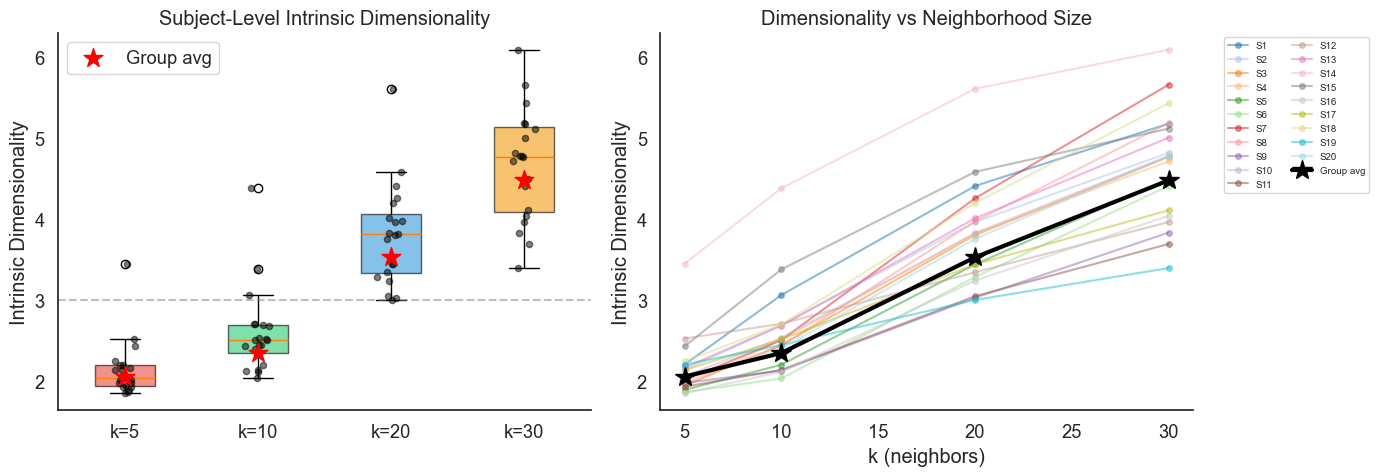


→ If individual subjects show d=3-8, the low-dimensional finding is robust
→ If individual subjects show d>15, the group average may be artificially low
→ Expect subjects to be slightly higher than group (noise inflates dimensionality)


In [42]:
# ============================================================
# Cell 6b: Subject-Level Intrinsic Dimensionality
# ============================================================

print("=" * 70)
print("SUBJECT-LEVEL INTRINSIC DIMENSIONALITY (MLE)")
print("=" * 70)

k_values = [5, 10, 20, 30]
subject_dims = {k: [] for k in k_values}

for s in range(n_subjects):
    subj_data = rsa_clean[s]  # (575, 56949)
    subj_scaled = StandardScaler().fit_transform(subj_data)
    
    print(f"\nSubject {s+1:2d}:", end="  ")
    for k in k_values:
        dim_mean, dim_std = estimate_intrinsic_dim_mle(subj_scaled, k=k)
        subject_dims[k].append(dim_mean)
        print(f"k={k}: {dim_mean:.2f}", end="  ")

# Summary statistics
print("\n\n" + "=" * 70)
print("SUMMARY ACROSS SUBJECTS")
print("=" * 70)
for k in k_values:
    vals = np.array(subject_dims[k])
    print(f"  k={k:2d}:  mean={vals.mean():.2f} ± {vals.std():.2f}  "
          f"range=[{vals.min():.2f}, {vals.max():.2f}]")

# Compare to group average
print("\nGROUP AVERAGE (for reference):")
for k in k_values:
    dim_mean, dim_std = estimate_intrinsic_dim_mle(group_scaled, k=k)
    print(f"  k={k:2d}:  {dim_mean:.2f} ± {dim_std:.2f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot across k values
box_data = [subject_dims[k] for k in k_values]
bp = axes[0].boxplot(box_data, labels=[f'k={k}' for k in k_values],
                     patch_artist=True)
colors_box = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

# Overlay individual subjects
for i, k in enumerate(k_values):
    x = np.random.normal(i + 1, 0.04, size=n_subjects)
    axes[0].scatter(x, subject_dims[k], c='black', s=20, alpha=0.5, zorder=3)

# Add group average as stars
for i, k in enumerate(k_values):
    group_dim, _ = estimate_intrinsic_dim_mle(group_scaled, k=k)
    axes[0].scatter(i + 1, group_dim, c='red', s=200, marker='*', 
                    zorder=4, label='Group avg' if i == 0 else '')

axes[0].legend()
axes[0].set_ylabel('Intrinsic Dimensionality')
axes[0].set_title('Subject-Level Intrinsic Dimensionality')
axes[0].axhline(3, color='gray', linestyle='--', alpha=0.5, label='d=3')

# Per-subject profile across k values
axes[1].set_prop_cycle(color=plt.cm.tab20(np.linspace(0, 1, n_subjects)))
for s in range(n_subjects):
    vals = [subject_dims[k][s] for k in k_values]
    axes[1].plot(k_values, vals, 'o-', alpha=0.5, markersize=4, 
                 label=f'S{s+1}')
    
# Group average in bold
group_vals = []
for k in k_values:
    gd, _ = estimate_intrinsic_dim_mle(group_scaled, k=k)
    group_vals.append(gd)
axes[1].plot(k_values, group_vals, 'k-', linewidth=3, marker='*',
             markersize=15, label='Group avg', zorder=5)

axes[1].set_xlabel('k (neighbors)')
axes[1].set_ylabel('Intrinsic Dimensionality')
axes[1].set_title('Dimensionality vs Neighborhood Size')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7, ncol=2)

sns.despine()
plt.tight_layout()
plt.show()

print("\n→ If individual subjects show d=3-8, the low-dimensional finding is robust")
print("→ If individual subjects show d>15, the group average may be artificially low")
print("→ Expect subjects to be slightly higher than group (noise inflates dimensionality)")

    The spatiotemporal structure of EEG-fMRI representational coupling is consistently low-dimensional across all 20 individual subjects, with intrinsic dimensionality estimated at approximately 2–6 depending on neighborhood scale. This is not an artifact of group averaging. The brain's pattern of representational similarity across ~57,000 cortical locations evolves over time along only a small number of independent spatial modes, and this constraint is a reliable feature of individual neural organization, not a statistical artifact of aggregation. This is a solid, publishable characterization of your data's manifold structure.

In [43]:
# ============================================================
# Disentangling Spatial vs Temporal Dimensionality
# ============================================================

print("=" * 70)
print("DISENTANGLING SPATIAL vs TEMPORAL DIMENSIONALITY")
print("=" * 70)

# --- 1. TEMPORAL dimensionality (for each voxel, how complex is the time series?) ---
# Subsample voxels, treat timepoints as the ambient space
# Transpose: (56949, 575) — each voxel is a sample in 575-dimensional time space
print("\n--- Temporal Dimensionality ---")
print("Question: How many independent temporal patterns exist across voxels?")

voxel_profiles = group_data.T  # (56949, 575)
voxel_profiles_scaled = StandardScaler().fit_transform(voxel_profiles)

for k in [5, 10, 20, 30]:
    dim_mean, dim_std = estimate_intrinsic_dim_mle(voxel_profiles_scaled, k=k)
    print(f"  k={k:2d}: {dim_mean:.2f} ± {dim_std:.2f}")

# --- 2. SPATIAL dimensionality at different time windows ---
# For specific time windows, how many spatial dimensions organize the voxels?
print("\n--- Spatial Dimensionality at Different Time Windows ---")
print("Question: At a given moment, how many spatial patterns are active?")

# Define time windows
windows = {
    'Pre-stimulus (-200 to 0ms)': (times >= -200) & (times <= 0),
    'Early (50-150ms)':           (times >= 50) & (times <= 150),
    'Mid (200-400ms)':            (times >= 200) & (times <= 400),
    'Late (500-800ms)':           (times >= 500) & (times <= 800),
}

for label, mask in windows.items():
    # Average within window: one spatial pattern per subject
    # Use all timepoints in window as samples, voxels as dimensions
    window_data = group_scaled[mask, :]  # (n_timepoints_in_window, 56949)
    
    n_tp = window_data.shape[0]
    if n_tp < 35:  # need enough samples for MLE
        print(f"  {label}: only {n_tp} timepoints, skipping k=30")
        k_use = [5, 10]
    else:
        k_use = [5, 10, 20, 30]
    
    print(f"  {label} ({n_tp} timepoints):", end="  ")
    for k in k_use:
        if k + 1 >= n_tp:
            continue
        dim_mean, dim_std = estimate_intrinsic_dim_mle(window_data, k=k)
        print(f"k={k}: {dim_mean:.2f}", end="  ")
    print()

# --- 3. Temporal dimensionality with downsampling to remove autocorrelation ---
print("\n--- Temporal Dimensionality (Downsampled to reduce autocorrelation) ---")
print("Question: Is the low dimensionality just from temporal smoothness?")

for step in [1, 3, 5, 10]:
    downsampled = group_scaled[::step, :]  # subsample every N timepoints
    n_tp = downsampled.shape[0]
    print(f"  Every {step}th timepoint ({n_tp} samples):", end="  ")
    for k in [5, 10]:
        if k + 1 >= n_tp:
            continue
        dim_mean, dim_std = estimate_intrinsic_dim_mle(downsampled, k=k)
        print(f"k={k}: {dim_mean:.2f}", end="  ")
    print()

print("\n" + "=" * 70)
print("INTERPRETATION")
print("=" * 70)
print("""
If TEMPORAL dimensionality (voxels as samples) is also low:
  → Few distinct temporal response profiles exist
  → The brain uses a small repertoire of temporal dynamics

If SPATIAL dimensionality varies across time windows:
  → Different processing stages engage different numbers of spatial modes
  → More spatial dimensions at mid-latency could suggest pathway divergence

If downsampling increases dimensionality substantially:
  → Part of the low dimensionality was from temporal autocorrelation
  → The 'true' spatial dimensionality is higher than the raw estimate

If downsampling does NOT increase dimensionality much:
  → The low dimensionality is genuine spatial structure, not temporal smoothness
""")

DISENTANGLING SPATIAL vs TEMPORAL DIMENSIONALITY

--- Temporal Dimensionality ---
Question: How many independent temporal patterns exist across voxels?
  k= 5: 7.12 ± 4.47
  k=10: 4.95 ± 1.23
  k=20: 4.08 ± 0.56
  k=30: 3.85 ± 0.47

--- Spatial Dimensionality at Different Time Windows ---
Question: At a given moment, how many spatial patterns are active?
  Pre-stimulus (-200 to 0ms) (96 timepoints):  k=5: 2.13  k=10: 2.52  k=20: 3.99  k=30: 5.05  
  Early (50-150ms) (48 timepoints):  k=5: 1.93  k=10: 2.19  k=20: 2.94  k=30: 3.56  
  Mid (200-400ms) (96 timepoints):  k=5: 1.96  k=10: 2.12  k=20: 3.20  k=30: 4.01  
  Late (500-800ms) (144 timepoints):  k=5: 2.06  k=10: 2.42  k=20: 3.62  k=30: 4.57  

--- Temporal Dimensionality (Downsampled to reduce autocorrelation) ---
Question: Is the low dimensionality just from temporal smoothness?
  Every 1th timepoint (575 samples):  k=5: 2.06  k=10: 2.35  
  Every 3th timepoint (192 samples):  k=5: 5.70  k=10: 7.32  
  Every 5th timepoint (115 sa

## Part 1-2 Testing the Three Pathway hypothesis

In [45]:
# ============================================================
# Fix the time axis everywhere
# ============================================================
t_start = -300  # ms
t_end = 2000    # ms (exclusive — 575 * 4ms = 2300ms range, so -300 to 1996ms)
times = np.arange(t_start, t_start + n_timepoints * 4, 4)  # -300, -296, -292, ..., 1996

print(f"Time axis: {times[0]}ms to {times[-1]}ms")
print(f"Timepoints: {len(times)}")
print(f"Interval: {times[1] - times[0]}ms")

# Verify
assert len(times) == n_timepoints, f"Mismatch: {len(times)} vs {n_timepoints}"

Time axis: -300ms to 1996ms
Timepoints: 575
Interval: 4ms


In [46]:
pre_mask = (times >= 100) & (times < 400)    # early post-stimulus
post_mask = (times >= 400) & (times <= 1200)  # your hypothesis window — extended

In [47]:
# ============================================================
# Sliding Window: How Does Voxel Manifold Dimensionality Evolve?
# ============================================================
window_width = 200  # ms
step_size = 50      # ms
k_test = 10

window_starts = np.arange(0, 1600, step_size)  # 0ms to 1600ms
dim_over_time = []
dim_over_time_subj = []

print("Computing voxel manifold dimensionality over time...")
for w_start in window_starts:
    w_end = w_start + window_width
    w_mask = (times >= w_start) & (times < w_end)
    n_tp = w_mask.sum()
    
    if n_tp < k_test + 2:
        dim_over_time.append(np.nan)
        dim_over_time_subj.append([np.nan] * n_subjects)
        continue
    
    # Group level
    w_voxel = group_data[w_mask, :].T  # (56949, n_tp)
    w_scaled = StandardScaler().fit_transform(w_voxel)
    d_group, _ = estimate_intrinsic_dim_mle(w_scaled, k=k_test)
    dim_over_time.append(d_group)
    
    # Subject level
    subj_dims = []
    for s in range(n_subjects):
        w_v = rsa_clean[s, w_mask, :].T
        w_v_sc = StandardScaler().fit_transform(w_v)
        d_s, _ = estimate_intrinsic_dim_mle(w_v_sc, k=k_test)
        subj_dims.append(d_s)
    dim_over_time_subj.append(subj_dims)
    
    print(f"  {w_start:4d}-{w_end:4d}ms: group d={d_group:.2f}, "
          f"subj mean={np.mean(subj_dims):.2f}")

dim_over_time = np.array(dim_over_time)
dim_over_time_subj = np.array(dim_over_time_subj)  # (n_windows, n_subjects)

# Center of each window for plotting
window_centers = window_starts + window_width / 2

Computing voxel manifold dimensionality over time...
     0- 200ms: group d=4.88, subj mean=4.82
    50- 250ms: group d=4.89, subj mean=4.84
   100- 300ms: group d=4.88, subj mean=4.86
   150- 350ms: group d=4.87, subj mean=4.87
   200- 400ms: group d=4.84, subj mean=4.89
   250- 450ms: group d=4.81, subj mean=4.89
   300- 500ms: group d=4.82, subj mean=4.90
   350- 550ms: group d=4.80, subj mean=4.90
   400- 600ms: group d=4.79, subj mean=4.90
   450- 650ms: group d=4.77, subj mean=4.89
   500- 700ms: group d=4.77, subj mean=4.88
   550- 750ms: group d=4.80, subj mean=4.87
   600- 800ms: group d=4.81, subj mean=4.86
   650- 850ms: group d=4.78, subj mean=4.85
   700- 900ms: group d=4.79, subj mean=4.84
   750- 950ms: group d=4.76, subj mean=4.82
   800-1000ms: group d=4.79, subj mean=4.82
   850-1050ms: group d=4.79, subj mean=4.82
   900-1100ms: group d=4.78, subj mean=4.82
   950-1150ms: group d=4.78, subj mean=4.81
  1000-1200ms: group d=4.79, subj mean=4.81
  1050-1250ms: group d=

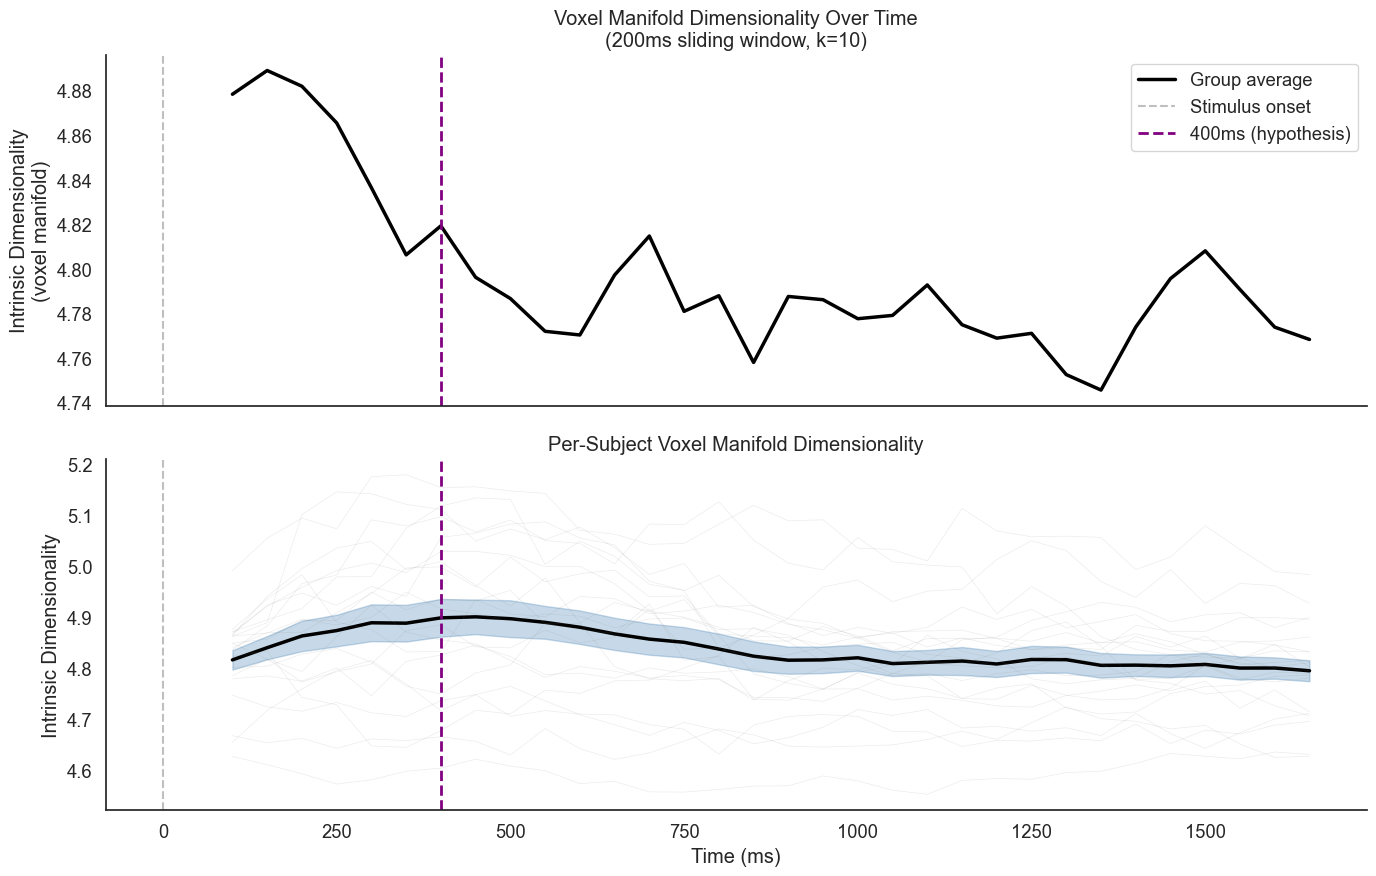

In [48]:
# ============================================================
# Sliding Window: Visualization
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# Panel A: Group dimensionality over time
axes[0].plot(window_centers, dim_over_time, 'k-', linewidth=2.5,
             label='Group average')
axes[0].axvline(0, color='gray', linestyle='--', alpha=0.5, label='Stimulus onset')
axes[0].axvline(400, color='purple', linestyle='--', linewidth=2,
                label='400ms (hypothesis)')
axes[0].set_ylabel('Intrinsic Dimensionality\n(voxel manifold)')
axes[0].set_title('Voxel Manifold Dimensionality Over Time\n'
                   '(200ms sliding window, k=10)')
axes[0].legend()

# Panel B: Subject-level with mean ± SEM
valid = ~np.isnan(dim_over_time_subj[:, 0])
subj_mean = np.nanmean(dim_over_time_subj, axis=1)
subj_sem = np.nanstd(dim_over_time_subj, axis=1) / np.sqrt(n_subjects)

axes[1].plot(window_centers[valid], subj_mean[valid], 'k-', linewidth=2.5)
axes[1].fill_between(window_centers[valid],
                     subj_mean[valid] - subj_sem[valid],
                     subj_mean[valid] + subj_sem[valid],
                     color='steelblue', alpha=0.3)

# Individual subjects
for s in range(n_subjects):
    axes[1].plot(window_centers[valid], dim_over_time_subj[valid, s],
                 '-', color='gray', alpha=0.15, linewidth=0.5)

axes[1].axvline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].axvline(400, color='purple', linestyle='--', linewidth=2)
axes[1].set_xlabel('Time (ms)')
axes[1].set_ylabel('Intrinsic Dimensionality')
axes[1].set_title('Per-Subject Voxel Manifold Dimensionality')

sns.despine()
plt.tight_layout()
plt.show()

Computing k=2 vs k=3 silhouette over time...
(This uses UMAP per window — will take a while)
     0- 300ms: k=2=0.3733, k=3=0.3418, diff=-0.0314 
   100- 400ms: k=2=0.3755, k=3=0.3354, diff=-0.0401 
   200- 500ms: k=2=0.3809, k=3=0.3197, diff=-0.0612 
   300- 600ms: k=2=0.3977, k=3=0.3308, diff=-0.0669 
   400- 700ms: k=2=0.3791, k=3=0.3274, diff=-0.0517 
   500- 800ms: k=2=0.3766, k=3=0.3150, diff=-0.0616 
   600- 900ms: k=2=0.3845, k=3=0.3321, diff=-0.0524 
   700-1000ms: k=2=0.3894, k=3=0.3383, diff=-0.0511 
   800-1100ms: k=2=0.3872, k=3=0.3509, diff=-0.0363 
   900-1200ms: k=2=0.3889, k=3=0.3223, diff=-0.0666 
  1000-1300ms: k=2=0.3926, k=3=0.3228, diff=-0.0698 
  1100-1400ms: k=2=0.3873, k=3=0.3340, diff=-0.0534 
  1200-1500ms: k=2=0.3894, k=3=0.3220, diff=-0.0675 
  1300-1600ms: k=2=0.3885, k=3=0.3498, diff=-0.0387 
  1400-1700ms: k=2=0.3931, k=3=0.3458, diff=-0.0473 


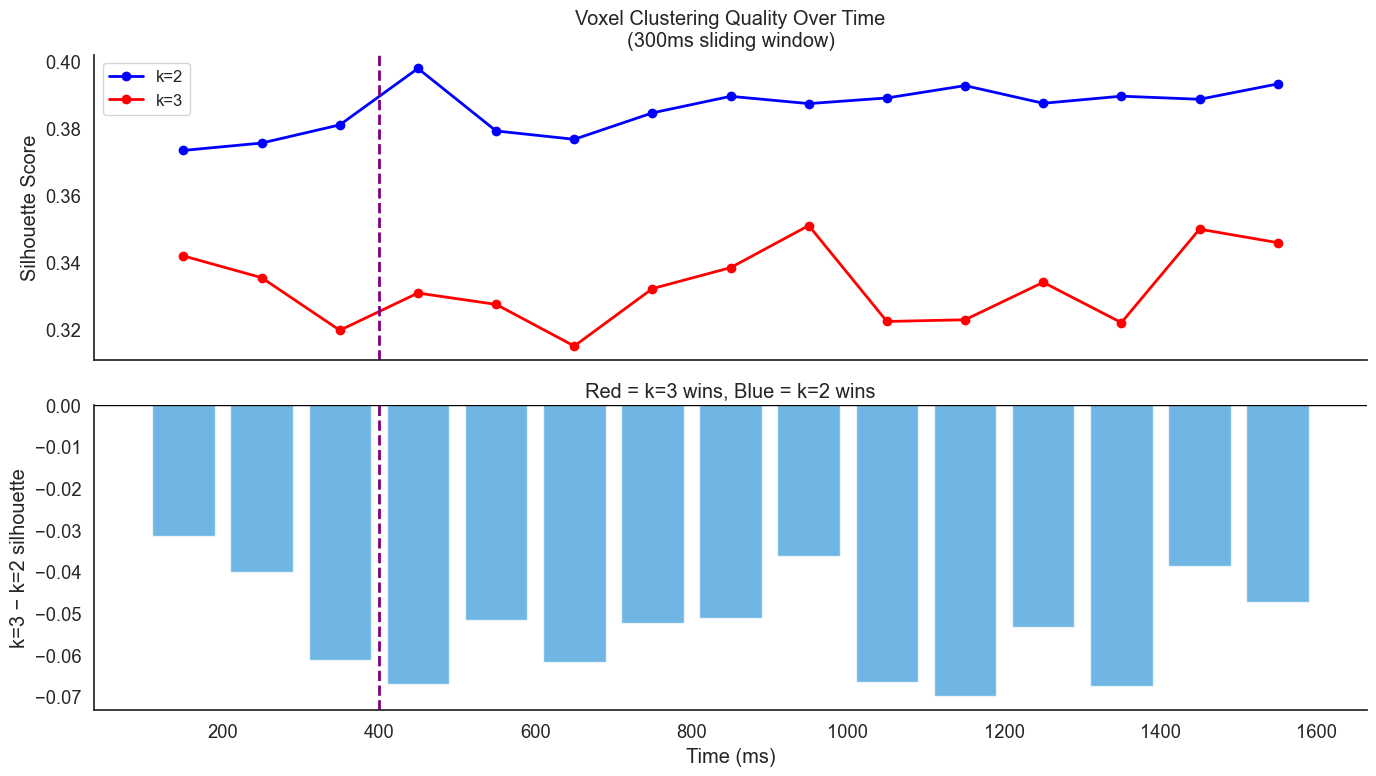


→ If k=3 advantage appears or increases after 400ms:
  The voxel manifold shifts from two-cluster to three-cluster
  structure, supporting the emergence of a third pathway


In [49]:
# ============================================================
# Sliding Window: k=2 vs k=3 Silhouette Over Time
# ============================================================
print("Computing k=2 vs k=3 silhouette over time...")
print("(This uses UMAP per window — will take a while)")

sil_k2_over_time = []
sil_k3_over_time = []

# Use wider windows and bigger steps to keep runtime manageable
window_width_clust = 300  # ms
step_size_clust = 100     # ms
window_starts_clust = np.arange(0, 1500, step_size_clust)

for w_start in window_starts_clust:
    w_end = w_start + window_width_clust
    w_mask = (times >= w_start) & (times < w_end)
    
    w_voxel = group_data[w_mask, :].T
    w_scaled = StandardScaler().fit_transform(w_voxel)
    
    reducer = umap.UMAP(n_components=3, n_neighbors=30, min_dist=0.05,
                        metric='correlation', random_state=42)
    emb_w = reducer.fit_transform(w_scaled)
    
    lab_2 = KMeans(2, n_init=30, random_state=42).fit_predict(emb_w)
    lab_3 = KMeans(3, n_init=30, random_state=42).fit_predict(emb_w)
    
    s2 = silhouette_score(emb_w, lab_2, sample_size=10000, random_state=42)
    s3 = silhouette_score(emb_w, lab_3, sample_size=10000, random_state=42)
    
    sil_k2_over_time.append(s2)
    sil_k3_over_time.append(s3)
    
    print(f"  {w_start:4d}-{w_end:4d}ms: k=2={s2:.4f}, k=3={s3:.4f}, "
          f"diff={s3-s2:+.4f} {'← k=3 wins!' if s3 > s2 else ''}")

window_centers_clust = window_starts_clust + window_width_clust / 2

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Panel A: Silhouette scores
axes[0].plot(window_centers_clust, sil_k2_over_time, 'b-o',
             linewidth=2, markersize=6, label='k=2')
axes[0].plot(window_centers_clust, sil_k3_over_time, 'r-o',
             linewidth=2, markersize=6, label='k=3')
axes[0].axvline(400, color='purple', linestyle='--', linewidth=2)
axes[0].legend(fontsize=12)
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('Voxel Clustering Quality Over Time\n'
                   '(300ms sliding window)')

# Panel B: k=3 minus k=2 advantage
advantage = np.array(sil_k3_over_time) - np.array(sil_k2_over_time)
colors_bar = ['#e74c3c' if a > 0 else '#3498db' for a in advantage]
axes[1].bar(window_centers_clust, advantage, width=step_size_clust * 0.8,
            color=colors_bar, alpha=0.7)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].axvline(400, color='purple', linestyle='--', linewidth=2)
axes[1].set_xlabel('Time (ms)')
axes[1].set_ylabel('k=3 − k=2 silhouette')
axes[1].set_title('Red = k=3 wins, Blue = k=2 wins')

sns.despine()
plt.tight_layout()
plt.show()

print("\n→ If k=3 advantage appears or increases after 400ms:")
print("  The voxel manifold shifts from two-cluster to three-cluster")
print("  structure, supporting the emergence of a third pathway")

---
## Part 2: PCA Component Brain Maps

Each PCA component is a spatial weight vector over 56,949 searchlight centers. By projecting these back to the brain, we can see what anatomy each component captures.

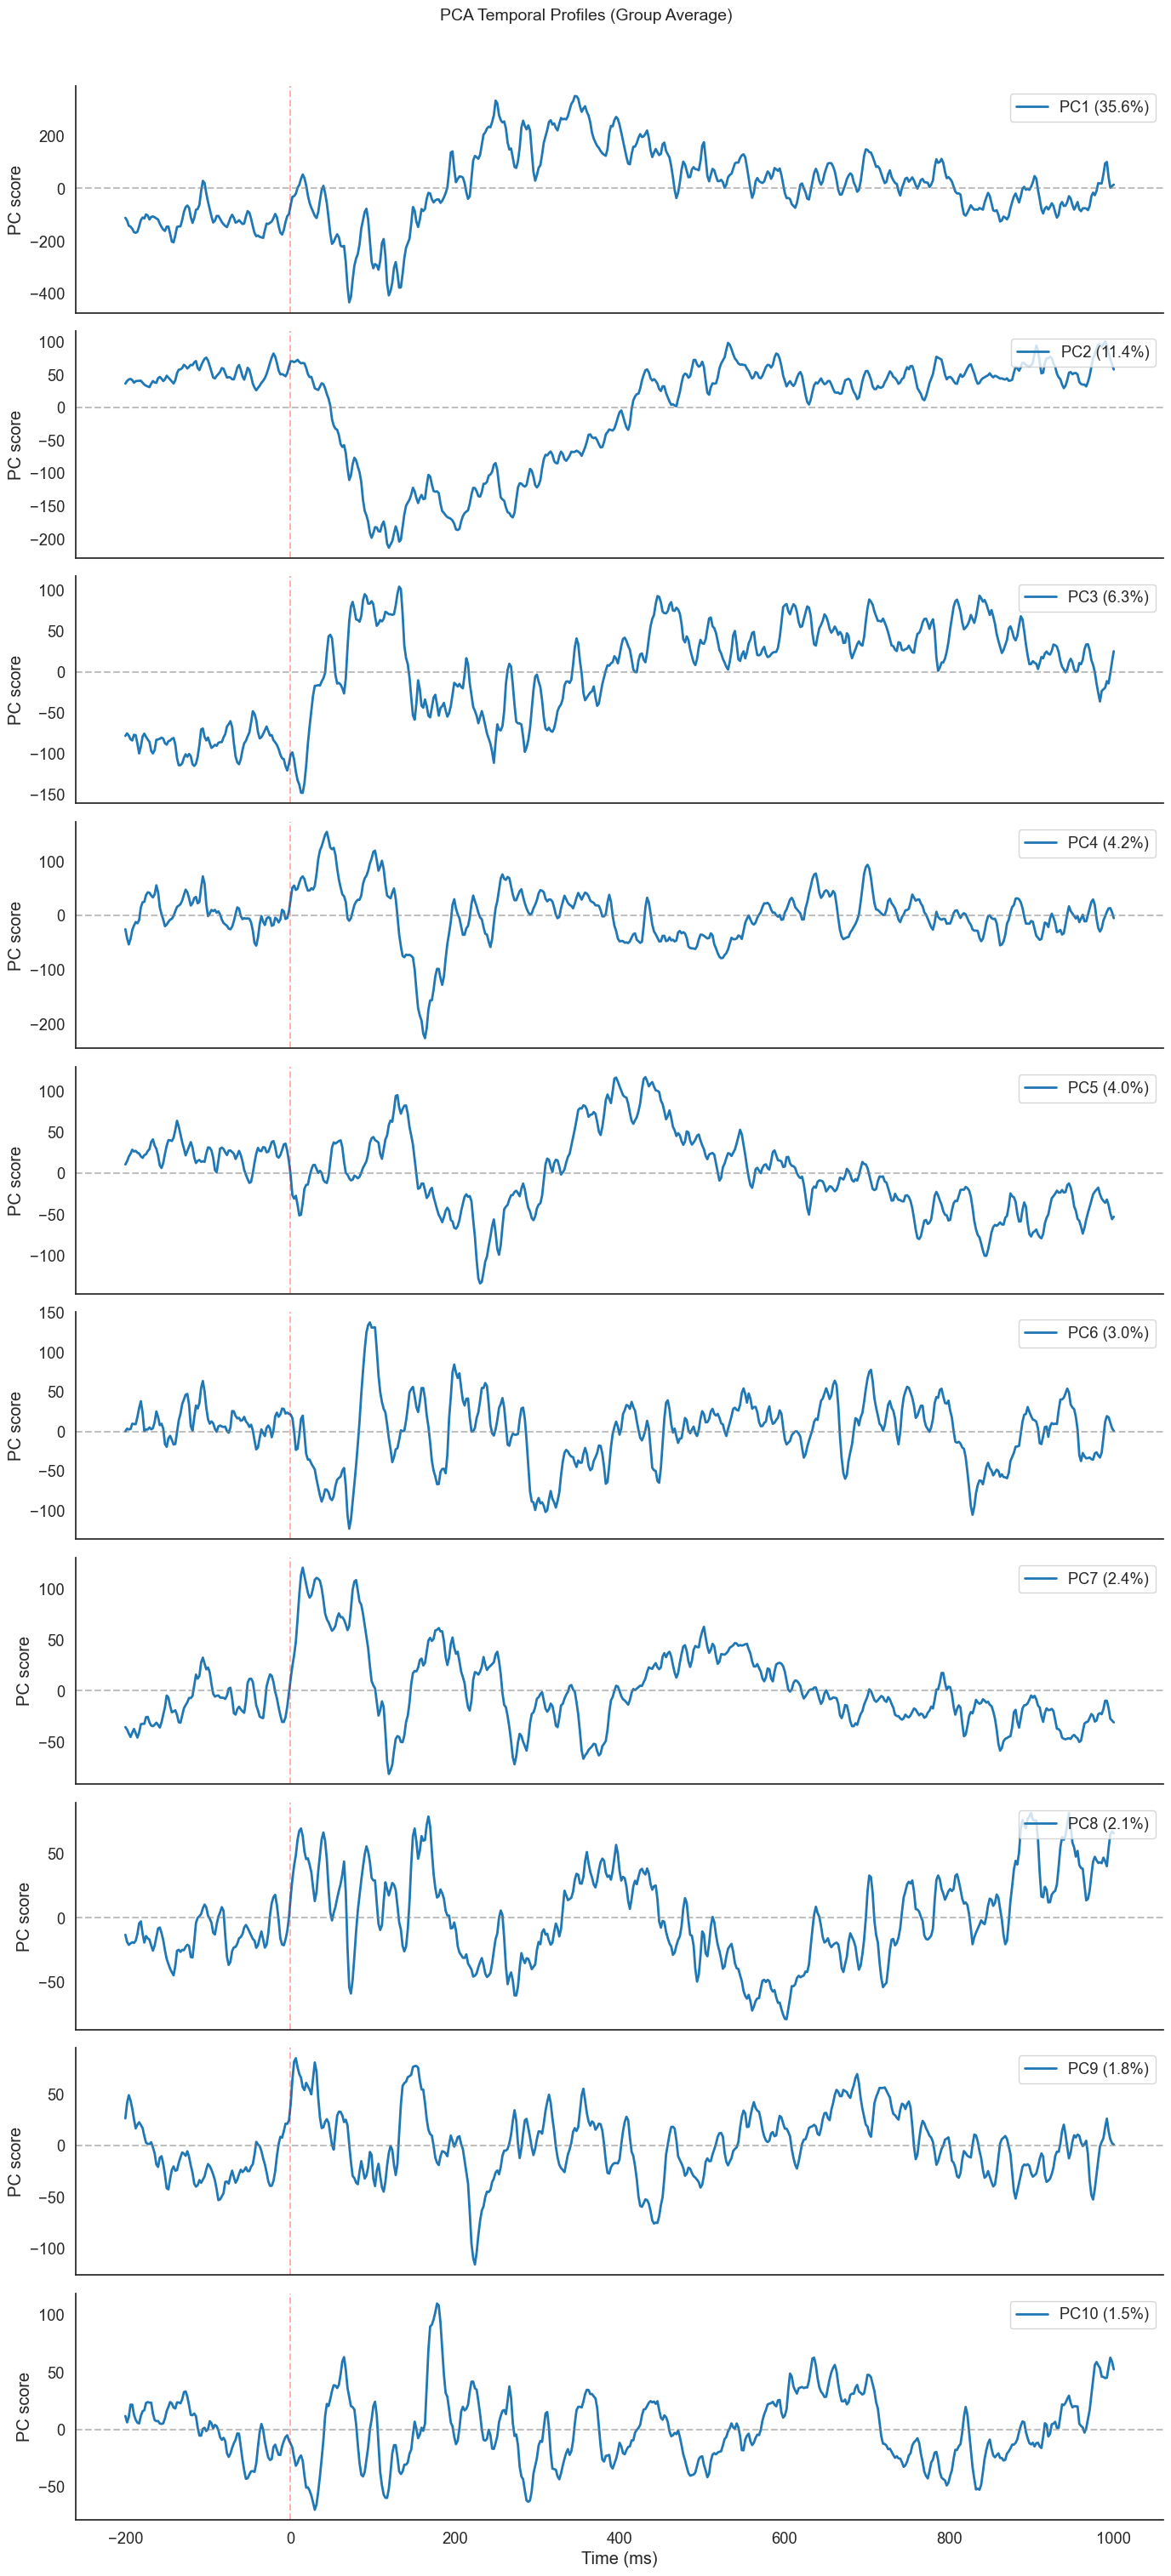

In [8]:
# ============================================================
# Cell 7: PCA Components — Temporal Profiles & Brain Maps
# ============================================================
n_pcs_to_show = 10
pca_for_vis = PCA(n_components=n_pcs_to_show)
scores = pca_for_vis.fit_transform(group_scaled)  # (575, n_pcs) — temporal profiles
loadings = pca_for_vis.components_  # (n_pcs, 56949) — spatial maps

fig, axes = plt.subplots(n_pcs_to_show, 1, figsize=(14, 3 * n_pcs_to_show), sharex=True)

for i in range(n_pcs_to_show):
    axes[i].plot(times, scores[:, i], linewidth=2,
                 label=f'PC{i+1} ({pca_for_vis.explained_variance_ratio_[i]*100:.1f}%)')
    axes[i].axhline(0, color='gray', linestyle='--', alpha=0.5)
    axes[i].axvline(0, color='red', linestyle='--', alpha=0.3)
    axes[i].legend(loc='upper right')
    axes[i].set_ylabel('PC score')

axes[-1].set_xlabel('Time (ms)')
fig.suptitle('PCA Temporal Profiles (Group Average)', fontsize=14, y=1.01)
sns.despine()
plt.tight_layout()
plt.show()

In [9]:
# ============================================================
# Cell 8: Save PCA Brain Maps for Visualization
# ============================================================
# The loadings (n_pcs, 56949) are spatial maps — each is a searchlight-space vector
# You need to map these back to 3D brain space using your searchlight mask

# Save as .npy for flexible use
np.save('pca_spatial_loadings.npy', loadings)
np.save('pca_temporal_scores.npy', scores)
print(f"Saved PCA loadings: {loadings.shape}")
print(f"Saved PCA scores: {scores.shape}")

# ---- If you have a brain mask nifti, reconstruct volume maps ----
# Uncomment and edit:
# mask_img = nib.load('brain_mask.nii.gz')
# mask_data = mask_img.get_fdata().astype(bool)
# for i in range(n_pcs_to_show):
#     vol = np.zeros(mask_data.shape)
#     vol[mask_data] = loadings[i]
#     nib.save(nib.Nifti1Image(vol, mask_img.affine), f'PC{i+1}_brainmap.nii.gz')
#     print(f"Saved PC{i+1}_brainmap.nii.gz")

Saved PCA loadings: (10, 56949)
Saved PCA scores: (575, 10)


---
## Part 3: UMAP Manifold Embedding

We run UMAP at multiple levels:
1. **No PCA** — full 56,949 features
2. **PCA 50** — moderate compression
3. **PCA 200** — mild compression

We compare all three to check robustness.

In [14]:
# ============================================================
# Cell 9: UMAP — Multiple PCA Truncation Levels
# ============================================================
if not HAS_UMAP:
    raise ImportError("Please install umap-learn: pip install umap-learn")

umap_params = dict(n_components=3, n_neighbors=15, min_dist=0.1, 
                   metric='euclidean', random_state=42)

# Prepare different input versions
# Based on your scree plot: 3 PCs=50%, 10≈70%, 18=80%, 37=90%, 61=95%
pca_levels = {
    'No PCA (all 56949)': group_scaled,
    'PCA-3 (50%)':   PCA(n_components=3,   random_state=42).fit_transform(group_scaled),
    'PCA-10 (~70%)': PCA(n_components=10,  random_state=42).fit_transform(group_scaled),
    'PCA-18 (80%)':  PCA(n_components=18,  random_state=42).fit_transform(group_scaled),
    'PCA-37 (90%)':  PCA(n_components=37,  random_state=42).fit_transform(group_scaled),
    'PCA-61 (95%)':  PCA(n_components=61,  random_state=42).fit_transform(group_scaled),
    'PCA-100':       PCA(n_components=100, random_state=42).fit_transform(group_scaled),
    'PCA-200':       PCA(n_components=200, random_state=42).fit_transform(group_scaled),
}

embeddings = {}
for label, data_in in pca_levels.items():
    print(f"Running UMAP on {label} ({data_in.shape})...")
    reducer = umap.UMAP(**umap_params)
    emb = reducer.fit_transform(data_in)
    embeddings[label] = emb
    print(f"  Done. Embedding shape: {emb.shape}")

print("\nAll UMAP embeddings computed.")

Running UMAP on No PCA (all 56949) ((575, 56949))...
  Done. Embedding shape: (575, 3)
Running UMAP on PCA-3 (50%) ((575, 3))...
  Done. Embedding shape: (575, 3)
Running UMAP on PCA-10 (~70%) ((575, 10))...
  Done. Embedding shape: (575, 3)
Running UMAP on PCA-18 (80%) ((575, 18))...
  Done. Embedding shape: (575, 3)
Running UMAP on PCA-37 (90%) ((575, 37))...
  Done. Embedding shape: (575, 3)
Running UMAP on PCA-61 (95%) ((575, 61))...
  Done. Embedding shape: (575, 3)
Running UMAP on PCA-100 ((575, 100))...
  Done. Embedding shape: (575, 3)
Running UMAP on PCA-200 ((575, 200))...
  Done. Embedding shape: (575, 3)

All UMAP embeddings computed.


In [19]:
embeddings

{'No PCA (all 56949)': array([[ 0.43368044, 11.204085  ,  7.4291945 ],
        [ 0.53646445, 11.275885  ,  7.405315  ],
        [ 0.46470812, 11.24443   ,  7.312635  ],
        ...,
        [-5.5172772 , 24.294664  , -1.166498  ],
        [-5.3880234 , 24.315317  , -1.2420367 ],
        [-5.4118433 , 24.244127  , -1.2400166 ]],
       shape=(575, 3), dtype=float32),
 'PCA-3 (50%)': array([[ 1.0841957e+01,  2.1513209e+00,  3.2179601e+00],
        [ 1.1100407e+01,  2.0040936e+00,  3.4438667e+00],
        [ 1.1485454e+01,  1.8233982e+00,  4.2701511e+00],
        ...,
        [-6.7492414e+00, -1.9123094e-01,  9.4777098e+00],
        [-6.5778999e+00, -6.5377583e-03,  9.4706306e+00],
        [-6.3868890e+00,  2.7910888e-01,  9.4954376e+00]],
       shape=(575, 3), dtype=float32),
 'PCA-10 (~70%)': array([[ 2.6948667,  7.836044 , 12.870203 ],
        [ 2.6102962,  7.802099 , 12.861537 ],
        [ 2.357036 ,  7.7130756, 12.834938 ],
        ...,
        [ 5.890597 ,  6.795355 , 32.657684 ],
 

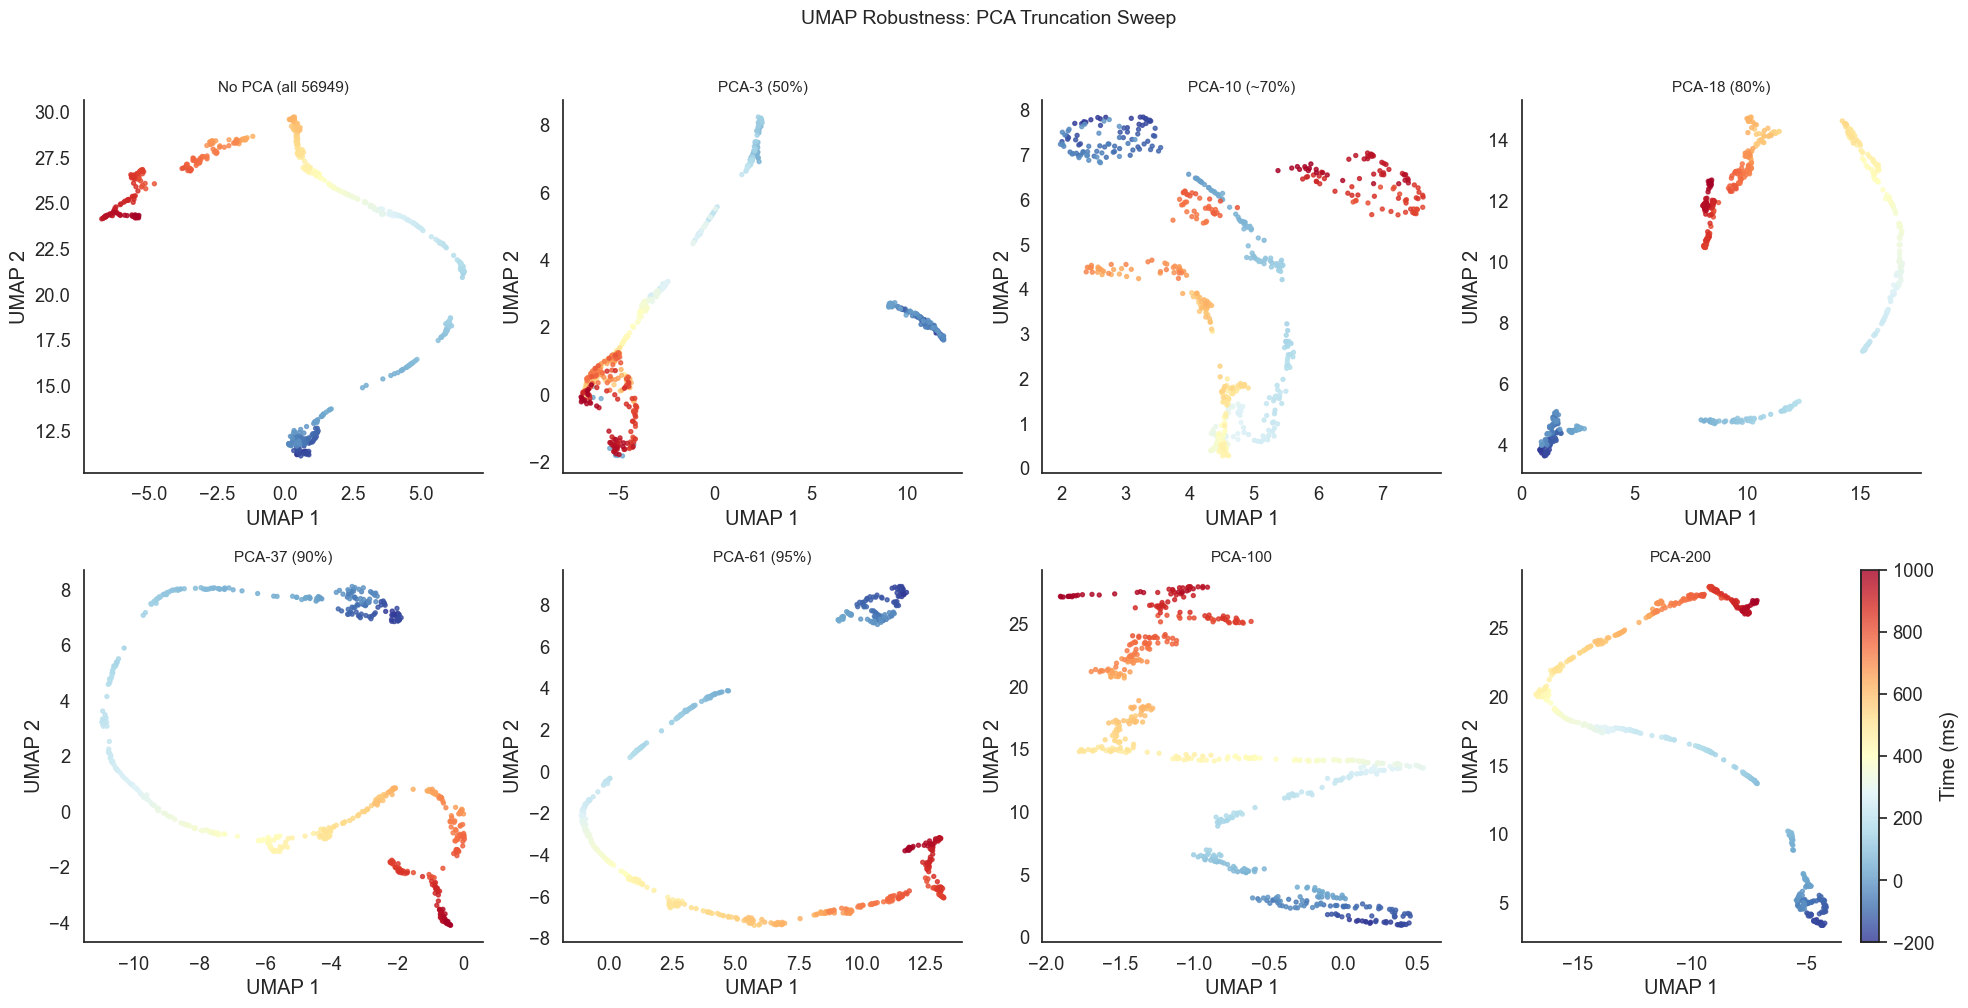


Procrustes disparity vs 'No PCA' reference:
  PCA-3 (50%)           disparity = 0.2160
  PCA-10 (~70%)         disparity = 0.1492
  PCA-18 (80%)          disparity = 0.1449
  PCA-37 (90%)          disparity = 0.1990
  PCA-61 (95%)          disparity = 0.1151
  PCA-100               disparity = 0.1496
  PCA-200               disparity = 0.1014

→ Lower disparity = more similar to full-feature embedding
→ If disparity is stable from PCA-37 onward, that's your safe truncation floor


In [15]:
# ============================================================
# Cell 10: Compare ALL UMAP Embeddings (Robustness Check)
# ============================================================
n_embs = len(embeddings)
ncols = 4
nrows = int(np.ceil(n_embs / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows))
axes = axes.flatten()

for idx, (label, emb) in enumerate(embeddings.items()):
    sc = axes[idx].scatter(emb[:, 0], emb[:, 1], c=times, cmap='RdYlBu_r',
                           s=8, alpha=0.8)
    axes[idx].set_title(label, fontsize=11)
    axes[idx].set_xlabel('UMAP 1')
    axes[idx].set_ylabel('UMAP 2')

# Hide unused axes
for idx in range(n_embs, len(axes)):
    axes[idx].set_visible(False)

plt.colorbar(sc, ax=axes[n_embs - 1], label='Time (ms)')
fig.suptitle('UMAP Robustness: PCA Truncation Sweep', fontsize=14, y=1.01)
sns.despine()
plt.tight_layout()
plt.show()

# --- Quantitative comparison: Procrustes alignment ---
from scipy.spatial import procrustes

print("\nProcrustes disparity vs 'No PCA' reference:")
ref_key = 'No PCA (all 56949)'
ref_emb = embeddings[ref_key]

for label, emb in embeddings.items():
    if label == ref_key:
        continue
    _, _, disparity = procrustes(ref_emb, emb)
    print(f"  {label:20s}  disparity = {disparity:.4f}")

print("\n→ Lower disparity = more similar to full-feature embedding")
print("→ If disparity is stable from PCA-37 onward, that's your safe truncation floor")

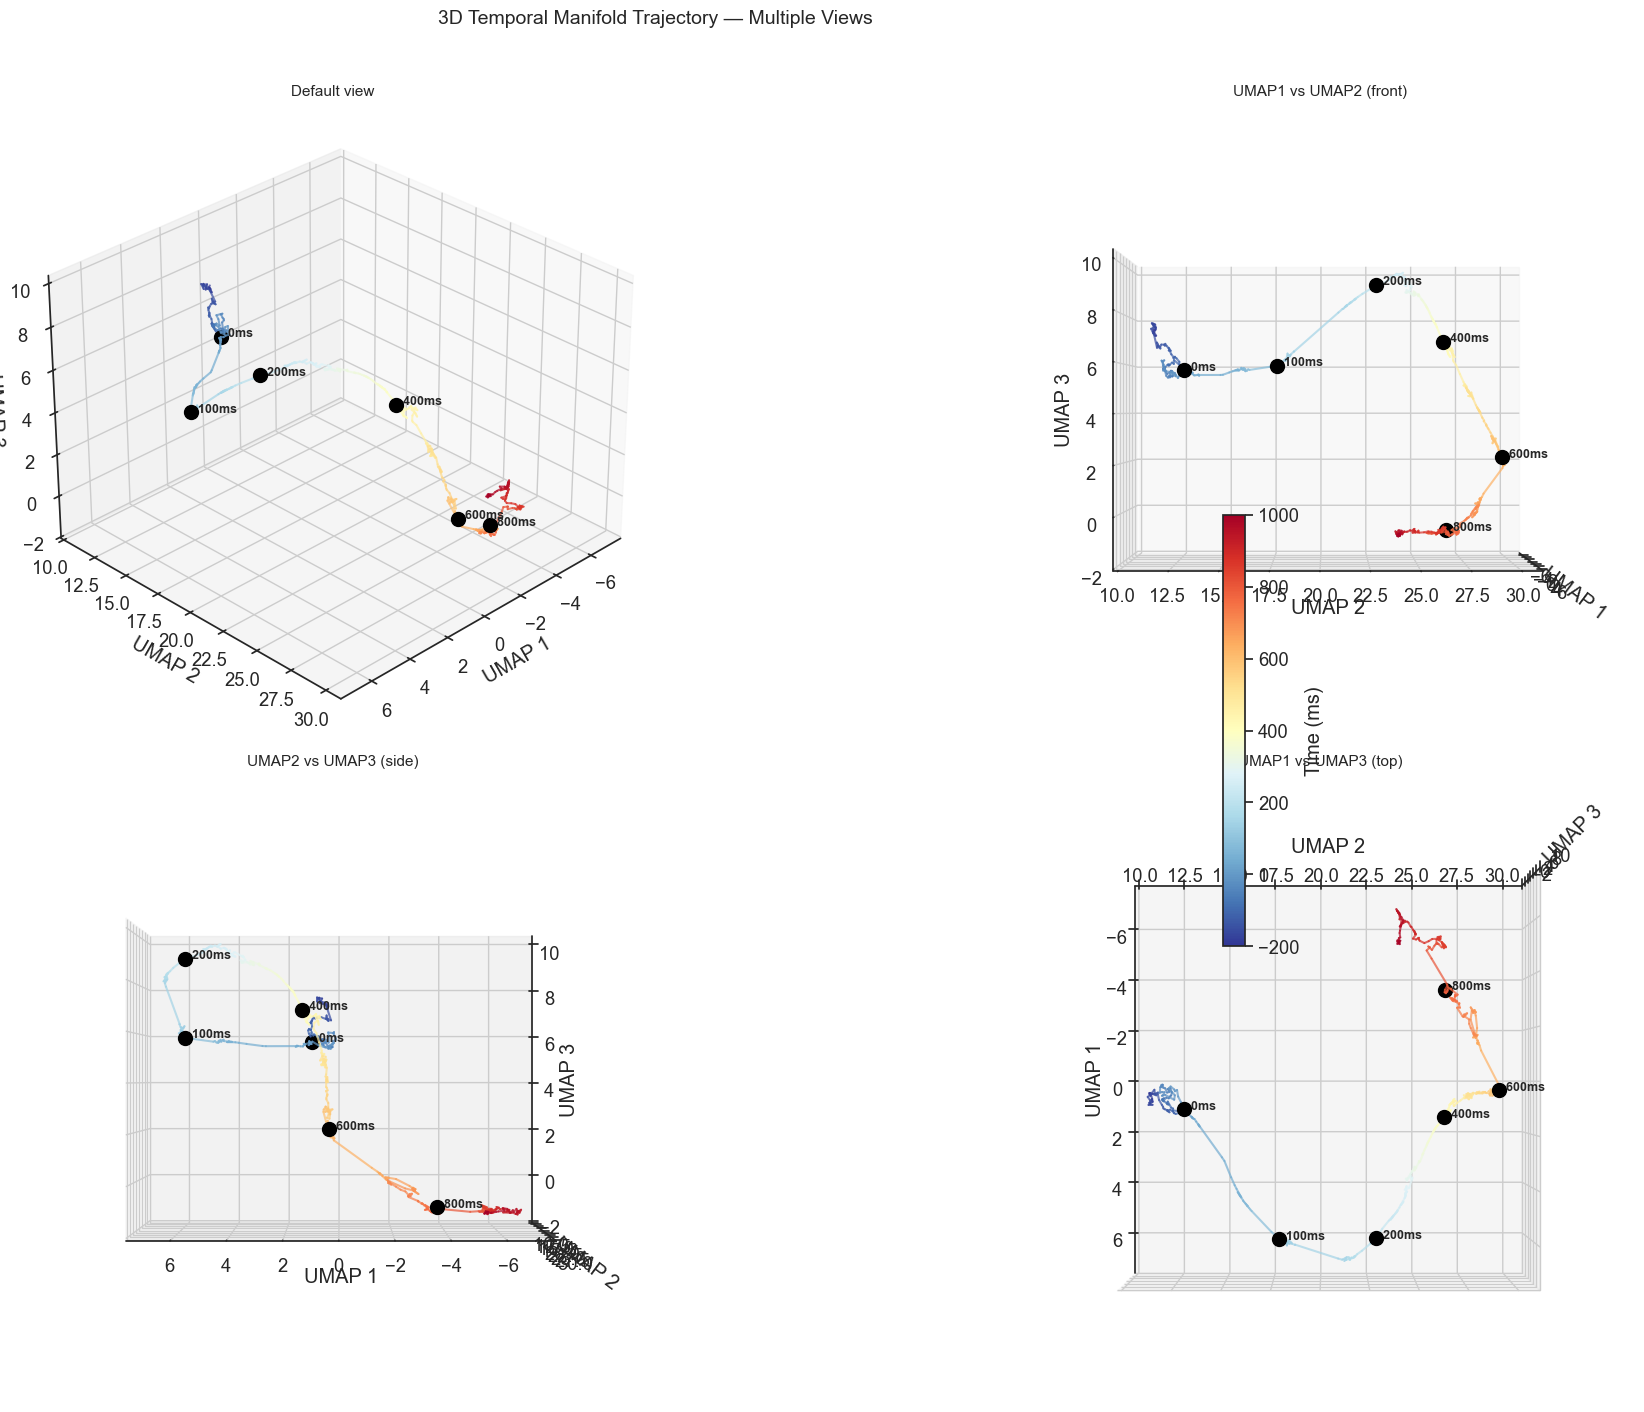

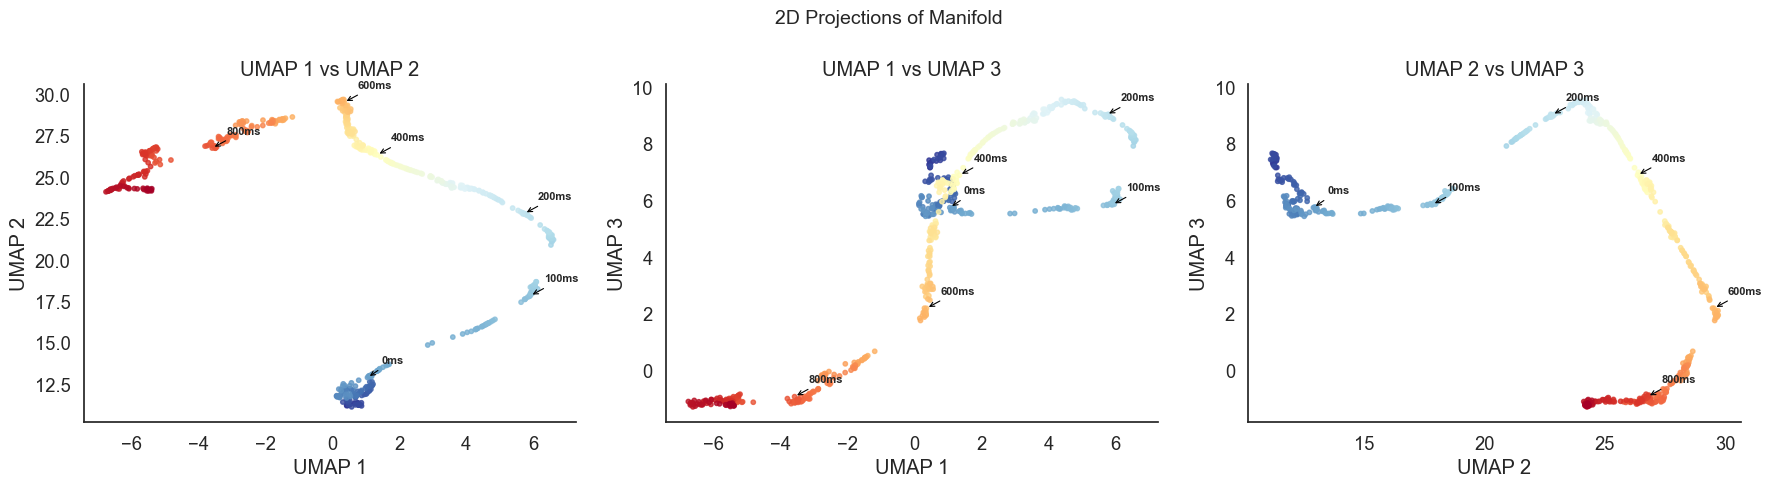

In [16]:
# ============================================================
# Cell 11: 3D UMAP Temporal Trajectory
# ============================================================
# Update key to match Cell 9
emb = embeddings['No PCA (all 56949)']  # matches the key from Cell 9

# --- Figure 1: 3D trajectory from multiple viewing angles ---
fig = plt.figure(figsize=(20, 14))

view_angles = [
    (30, 45,   'Default view'),
    (0,  0,    'UMAP1 vs UMAP2 (front)'),
    (0,  90,   'UMAP2 vs UMAP3 (side)'),
    (90, 0,    'UMAP1 vs UMAP3 (top)'),
]

norm = Normalize(vmin=times.min(), vmax=times.max())
colors = cm.RdYlBu_r(norm(times))

key_times_ms = [0, 100, 200, 400, 600, 800]

for idx, (elev, azim, title) in enumerate(view_angles):
    ax = fig.add_subplot(2, 2, idx + 1, projection='3d')
    
    # Trajectory line
    for i in range(len(emb) - 1):
        ax.plot(emb[i:i+2, 0], emb[i:i+2, 1], emb[i:i+2, 2],
                color=colors[i], linewidth=1.5, alpha=0.7)
    
    # Key timepoints
    for t_ms in key_times_ms:
        t_idx = np.argmin(np.abs(times - t_ms))
        ax.scatter(*emb[t_idx], s=100, c='black', marker='o', zorder=5)
        ax.text(emb[t_idx, 0], emb[t_idx, 1], emb[t_idx, 2],
                f'  {t_ms}ms', fontsize=9, fontweight='bold')
    
    ax.view_init(elev=elev, azim=azim)
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    ax.set_zlabel('UMAP 3')
    ax.set_title(title, fontsize=11)

sm = plt.cm.ScalarMappable(cmap='RdYlBu_r', norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=fig.axes, label='Time (ms)', shrink=0.4, pad=0.1)
fig.suptitle('3D Temporal Manifold Trajectory — Multiple Views', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# --- Figure 2: 2D projections with cluster overlay (if Cell 16/17 already run) ---
try:
    _ = cluster_labels  # check if clustering has been done
    HAS_CLUSTERS = True
except NameError:
    HAS_CLUSTERS = False

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
pairs = [(0, 1, 'UMAP 1', 'UMAP 2'),
         (0, 2, 'UMAP 1', 'UMAP 3'),
         (1, 2, 'UMAP 2', 'UMAP 3')]

for idx, (d1, d2, xl, yl) in enumerate(pairs):
    if HAS_CLUSTERS:
        cluster_colors_map = ['#e74c3c', '#2ecc71', '#3498db']
        for c in range(3):
            mask_c = cluster_labels == c
            axes[idx].scatter(emb[mask_c, d1], emb[mask_c, d2],
                              c=cluster_colors_map[c], s=12, alpha=0.6,
                              label=f'Cluster {c+1}')
        axes[idx].legend(fontsize=9)
    else:
        axes[idx].scatter(emb[:, d1], emb[:, d2], c=times, cmap='RdYlBu_r',
                          s=10, alpha=0.8)
    
    # Annotate key timepoints
    for t_ms in key_times_ms:
        t_idx = np.argmin(np.abs(times - t_ms))
        axes[idx].annotate(f'{t_ms}ms', xy=(emb[t_idx, d1], emb[t_idx, d2]),
                           fontsize=8, fontweight='bold',
                           arrowprops=dict(arrowstyle='->', color='black', lw=0.8),
                           textcoords='offset points', xytext=(10, 10))
    
    axes[idx].set_xlabel(xl)
    axes[idx].set_ylabel(yl)
    axes[idx].set_title(f'{xl} vs {yl}')

fig.suptitle('2D Projections of Manifold', fontsize=14)
sns.despine()
plt.tight_layout()
plt.show()

---
## Part 4: UMAP Hyperparameter Robustness

UMAP results can vary with `n_neighbors` and `min_dist`. We check whether the manifold structure (especially any branching) is stable.

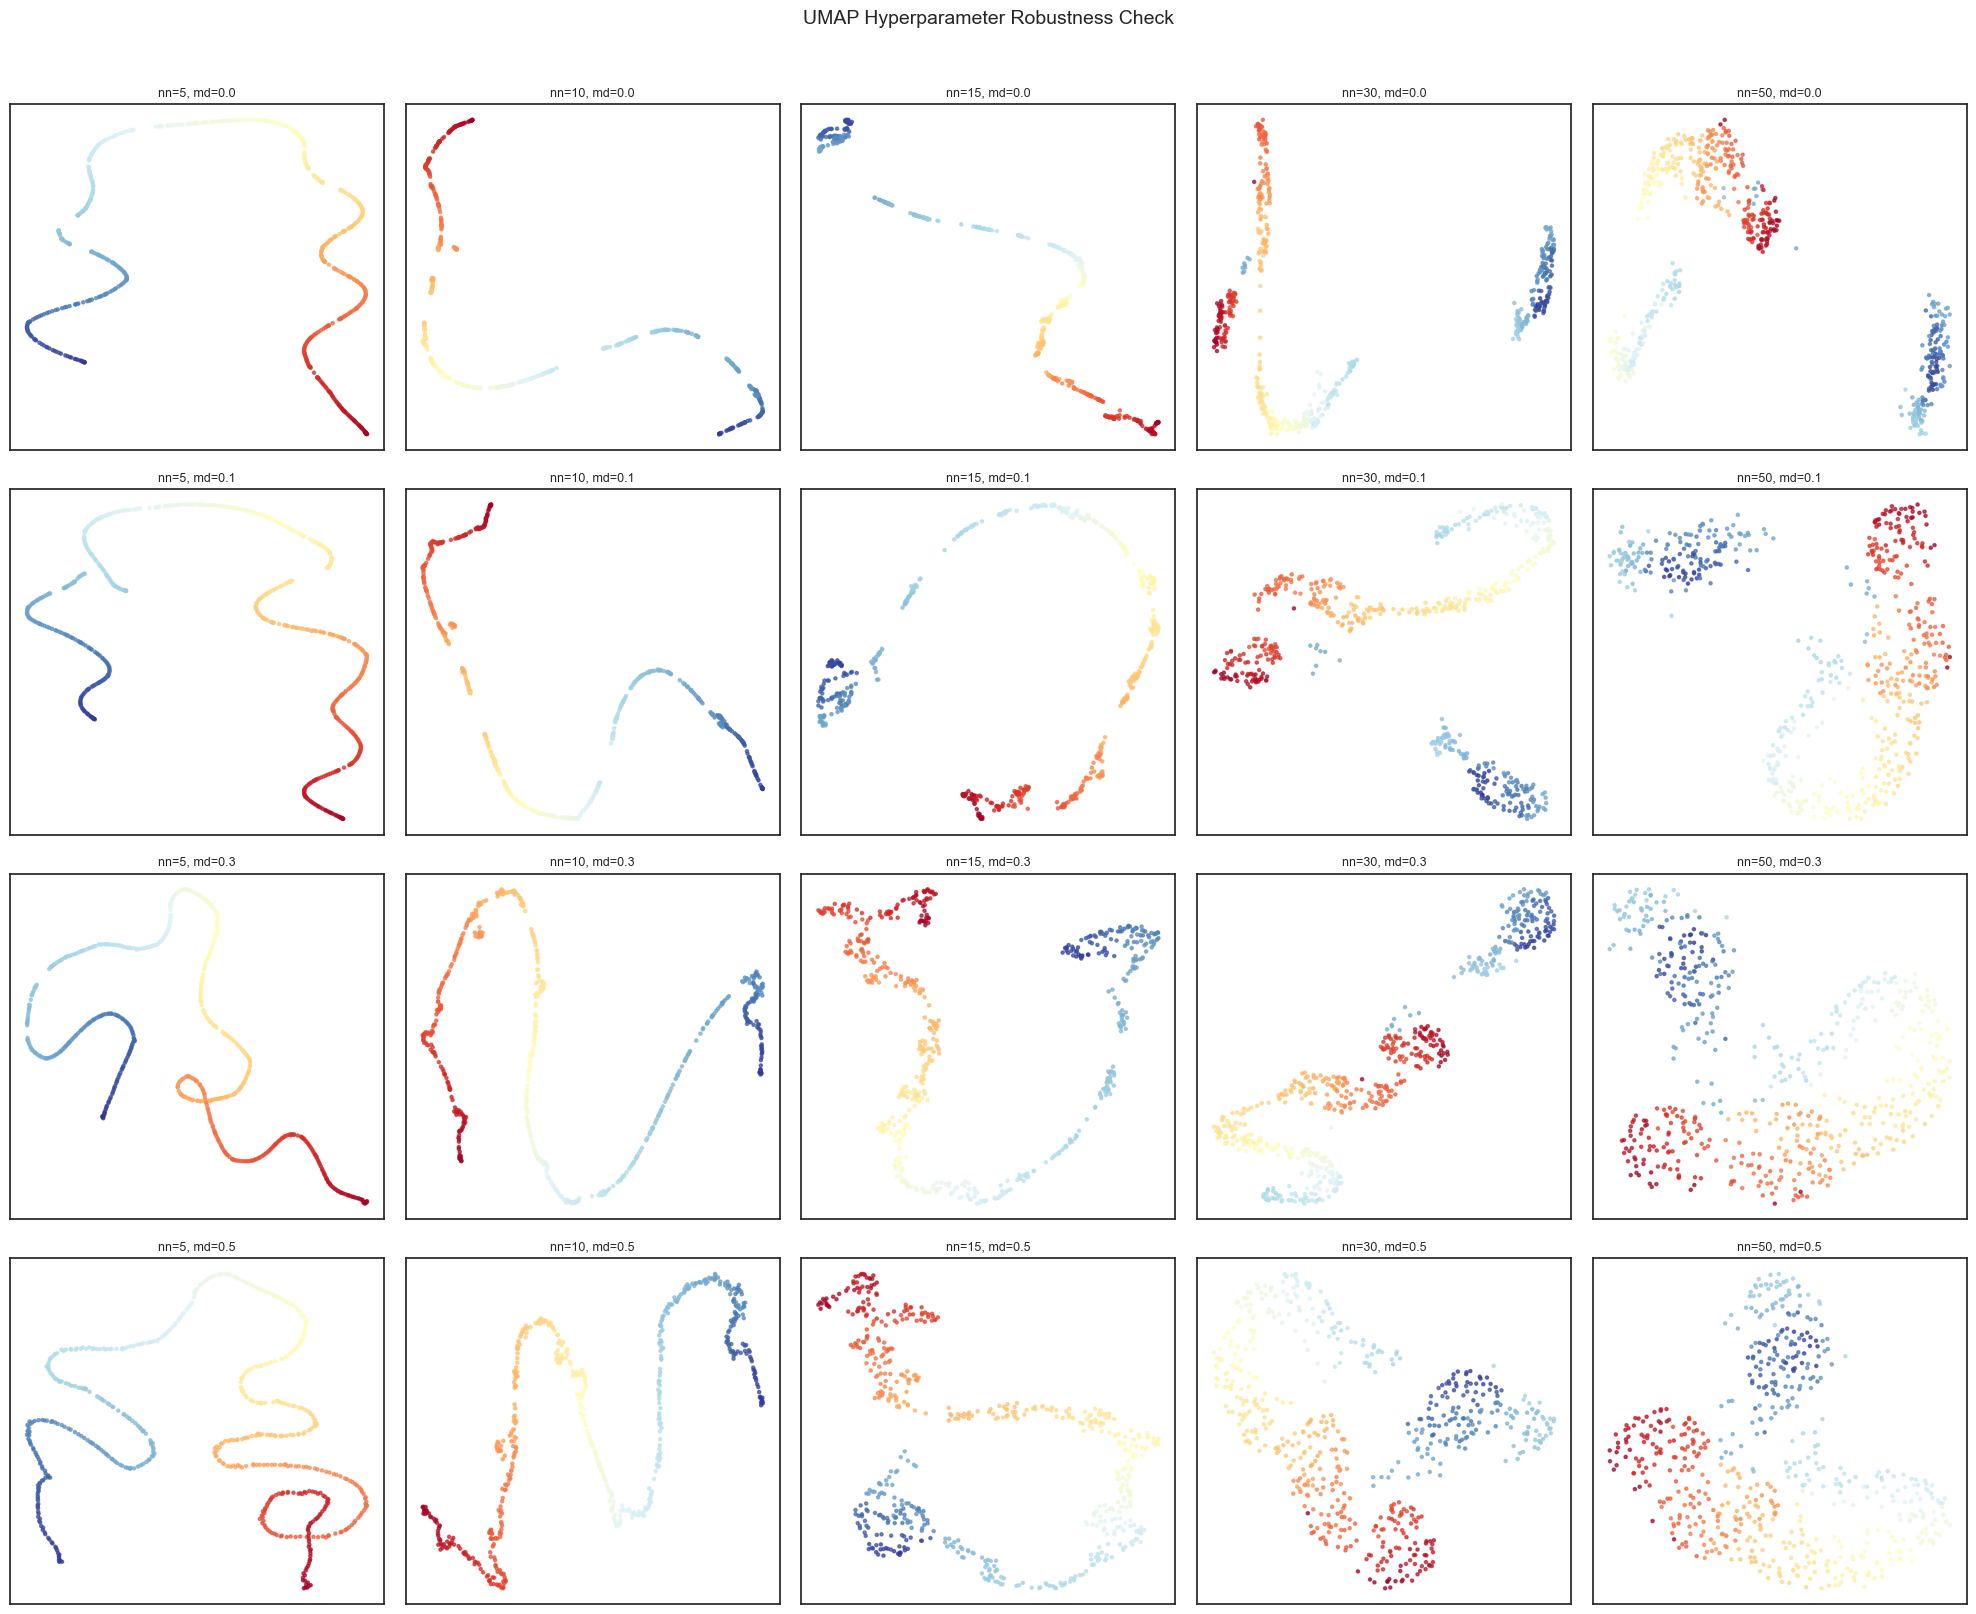

Look for consistent structure (branching, clusters) across parameters.
Structure that only appears at one setting is likely an artifact.


In [17]:
# ============================================================
# Cell 12: UMAP Hyperparameter Sweep
# ============================================================
n_neighbors_list = [5, 10, 15, 30, 50]
min_dist_list = [0.0, 0.1, 0.3, 0.5]

fig, axes = plt.subplots(len(min_dist_list), len(n_neighbors_list),
                         figsize=(4 * len(n_neighbors_list), 4 * len(min_dist_list)))

for i, md in enumerate(min_dist_list):
    for j, nn in enumerate(n_neighbors_list):
        reducer = umap.UMAP(n_components=2, n_neighbors=nn, min_dist=md,
                            random_state=42)
        emb_2d = reducer.fit_transform(group_scaled)
        axes[i, j].scatter(emb_2d[:, 0], emb_2d[:, 1], c=times,
                           cmap='RdYlBu_r', s=5, alpha=0.7)
        axes[i, j].set_title(f'nn={nn}, md={md}', fontsize=9)
        axes[i, j].set_xticks([])
        axes[i, j].set_yticks([])

fig.suptitle('UMAP Hyperparameter Robustness Check', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print("Look for consistent structure (branching, clusters) across parameters.")
print("Structure that only appears at one setting is likely an artifact.")

---
## Part 5: Map Manifold Dimensions Back to Anatomy

For each UMAP dimension, we correlate it with the original voxel-level data to see which brain regions drive each manifold direction. This is the key step for identifying ventral, dorsal, and middle pathways.

In [20]:
# ============================================================
# Cell 13: Anatomical Mapping of Manifold Dimensions
# ============================================================
# Use the best UMAP 3D embedding
emb_3d = embeddings['No PCA (all 56949)'] # (575, 3)

# Correlate each manifold dimension with each voxel's temporal profile
brain_maps_umap = np.zeros((3, n_voxels))

print("Computing brain maps for UMAP dimensions...")
for dim in range(3):
    for v in range(n_voxels):
        r, _ = stats.pearsonr(emb_3d[:, dim], group_data[:, v])
        brain_maps_umap[dim, v] = r
    print(f"  UMAP dim {dim+1}: done. "
          f"Max |r| = {np.abs(brain_maps_umap[dim]).max():.4f}")

# Save
np.save('umap_brain_maps.npy', brain_maps_umap)
print(f"\nSaved umap_brain_maps.npy: {brain_maps_umap.shape}")

# ---- Reconstruct to nifti if mask available ----
# Uncomment:
# for dim in range(3):
#     vol = np.zeros(mask_data.shape)
#     vol[mask_data] = brain_maps_umap[dim]
#     nib.save(nib.Nifti1Image(vol, mask_img.affine), f'UMAP_dim{dim+1}_brainmap.nii.gz')
#     print(f"Saved UMAP_dim{dim+1}_brainmap.nii.gz")

Computing brain maps for UMAP dimensions...
  UMAP dim 1: done. Max |r| = 0.8268
  UMAP dim 2: done. Max |r| = 0.8056
  UMAP dim 3: done. Max |r| = 0.8534

Saved umap_brain_maps.npy: (3, 56949)


In [21]:
# ============================================================
# Cell 14: Vectorized Version (Much Faster)
# ============================================================
# The voxel-by-voxel loop in Cell 13 is slow. Here's a vectorized version.

def correlate_manifold_to_brain(embedding, brain_data):
    """
    Correlate each manifold dimension with each voxel.
    embedding: (n_timepoints, n_dims)
    brain_data: (n_timepoints, n_voxels)
    Returns: (n_dims, n_voxels) correlation maps
    """
    # Z-score both
    emb_z = (embedding - embedding.mean(0)) / (embedding.std(0) + 1e-10)
    brain_z = (brain_data - brain_data.mean(0)) / (brain_data.std(0) + 1e-10)
    
    # Correlation = dot product of z-scored data / n
    corr_maps = emb_z.T @ brain_z / len(embedding)
    return corr_maps

brain_maps_umap_fast = correlate_manifold_to_brain(emb_3d, group_data)
print(f"Brain maps shape: {brain_maps_umap_fast.shape}")

# Verify matches slow version (if both were run)
if brain_maps_umap.any():
    max_diff = np.abs(brain_maps_umap - brain_maps_umap_fast).max()
    print(f"Max difference from loop version: {max_diff:.8f}")

Brain maps shape: (3, 56949)
Max difference from loop version: 0.00000012


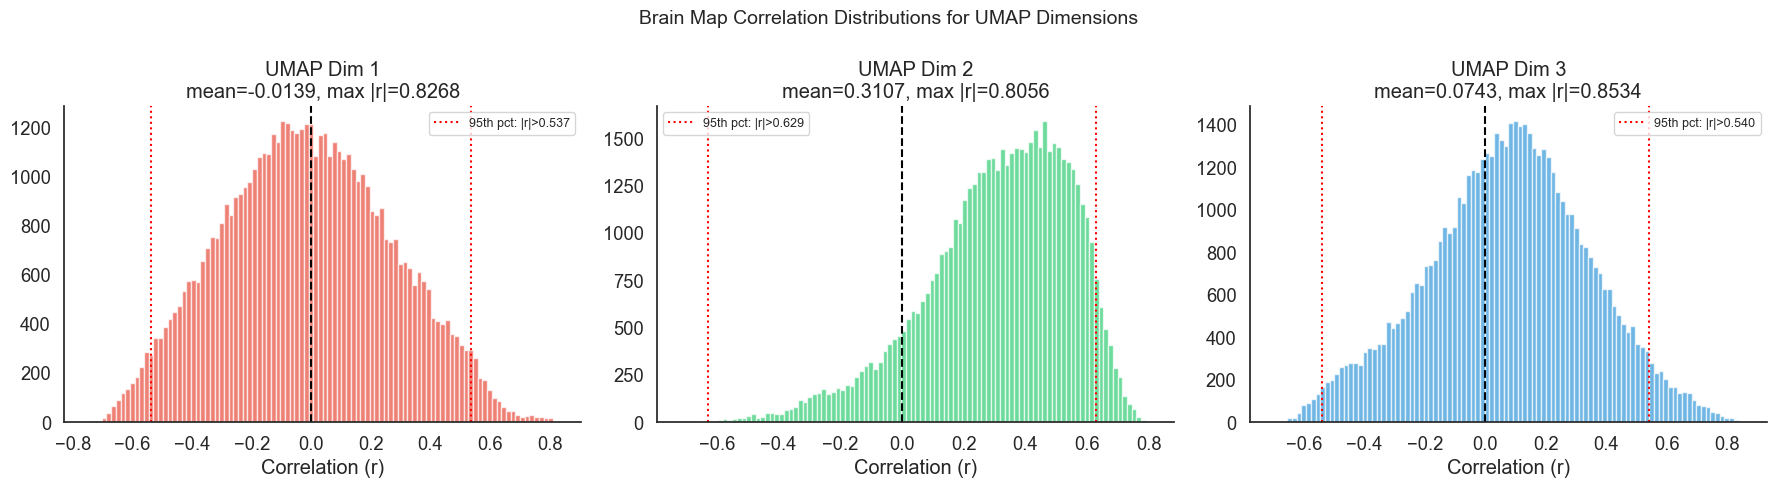

In [22]:
# ============================================================
# Cell 15: Distribution of Brain Map Correlations
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
dim_labels = ['UMAP Dim 1', 'UMAP Dim 2', 'UMAP Dim 3']
colors_dim = ['#e74c3c', '#2ecc71', '#3498db']

for i in range(3):
    vals = brain_maps_umap_fast[i]
    axes[i].hist(vals, bins=100, color=colors_dim[i], alpha=0.7, edgecolor='white')
    axes[i].axvline(0, color='black', linestyle='--')
    
    # Mark thresholds
    thresh = np.percentile(np.abs(vals), 95)
    axes[i].axvline(thresh, color='red', linestyle=':', label=f'95th pct: |r|>{thresh:.3f}')
    axes[i].axvline(-thresh, color='red', linestyle=':')
    
    axes[i].set_title(f'{dim_labels[i]}\n'
                      f'mean={vals.mean():.4f}, max |r|={np.abs(vals).max():.4f}')
    axes[i].set_xlabel('Correlation (r)')
    axes[i].legend(fontsize=9)

fig.suptitle('Brain Map Correlation Distributions for UMAP Dimensions', fontsize=14)
sns.despine()
plt.tight_layout()
plt.show()

---
## Part 6: Pathway Identification via Clustering

If three pathways exist, timepoints should cluster into groups that correspond to distinct brain networks. We test this with temporal clustering on the manifold.

  k=2: silhouette = 0.5344
  k=3: silhouette = 0.6005
  k=4: silhouette = 0.6110
  k=5: silhouette = 0.6395
  k=6: silhouette = 0.6389
  k=7: silhouette = 0.6444
  k=8: silhouette = 0.6585


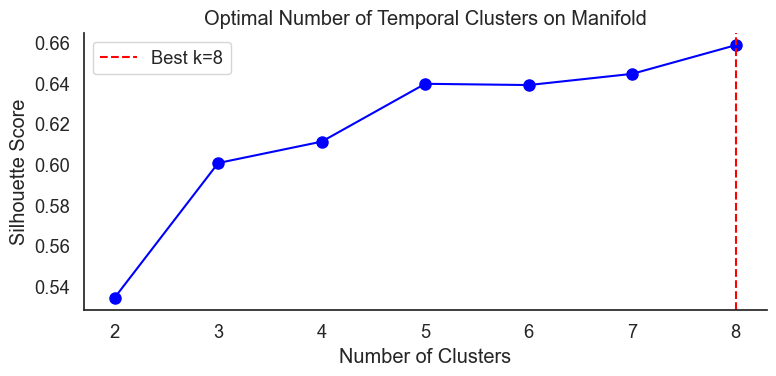


→ Best k = 8 (silhouette = 0.6585)
→ If best k=3, that directly supports the three-pathway hypothesis


In [23]:
# ============================================================
# Cell 16: Optimal Number of Clusters
# ============================================================
# Test k=2 through k=8
k_range = range(2, 9)
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = kmeans.fit_predict(emb_3d)
    sil = silhouette_score(emb_3d, labels)
    silhouette_scores.append(sil)
    print(f"  k={k}: silhouette = {sil:.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(k_range), silhouette_scores, 'bo-', markersize=8)
best_k = list(k_range)[np.argmax(silhouette_scores)]
ax.axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k}')
ax.set_xlabel('Number of Clusters')
ax.set_ylabel('Silhouette Score')
ax.set_title('Optimal Number of Temporal Clusters on Manifold')
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

print(f"\n→ Best k = {best_k} (silhouette = {max(silhouette_scores):.4f})")
print(f"→ If best k=3, that directly supports the three-pathway hypothesis")

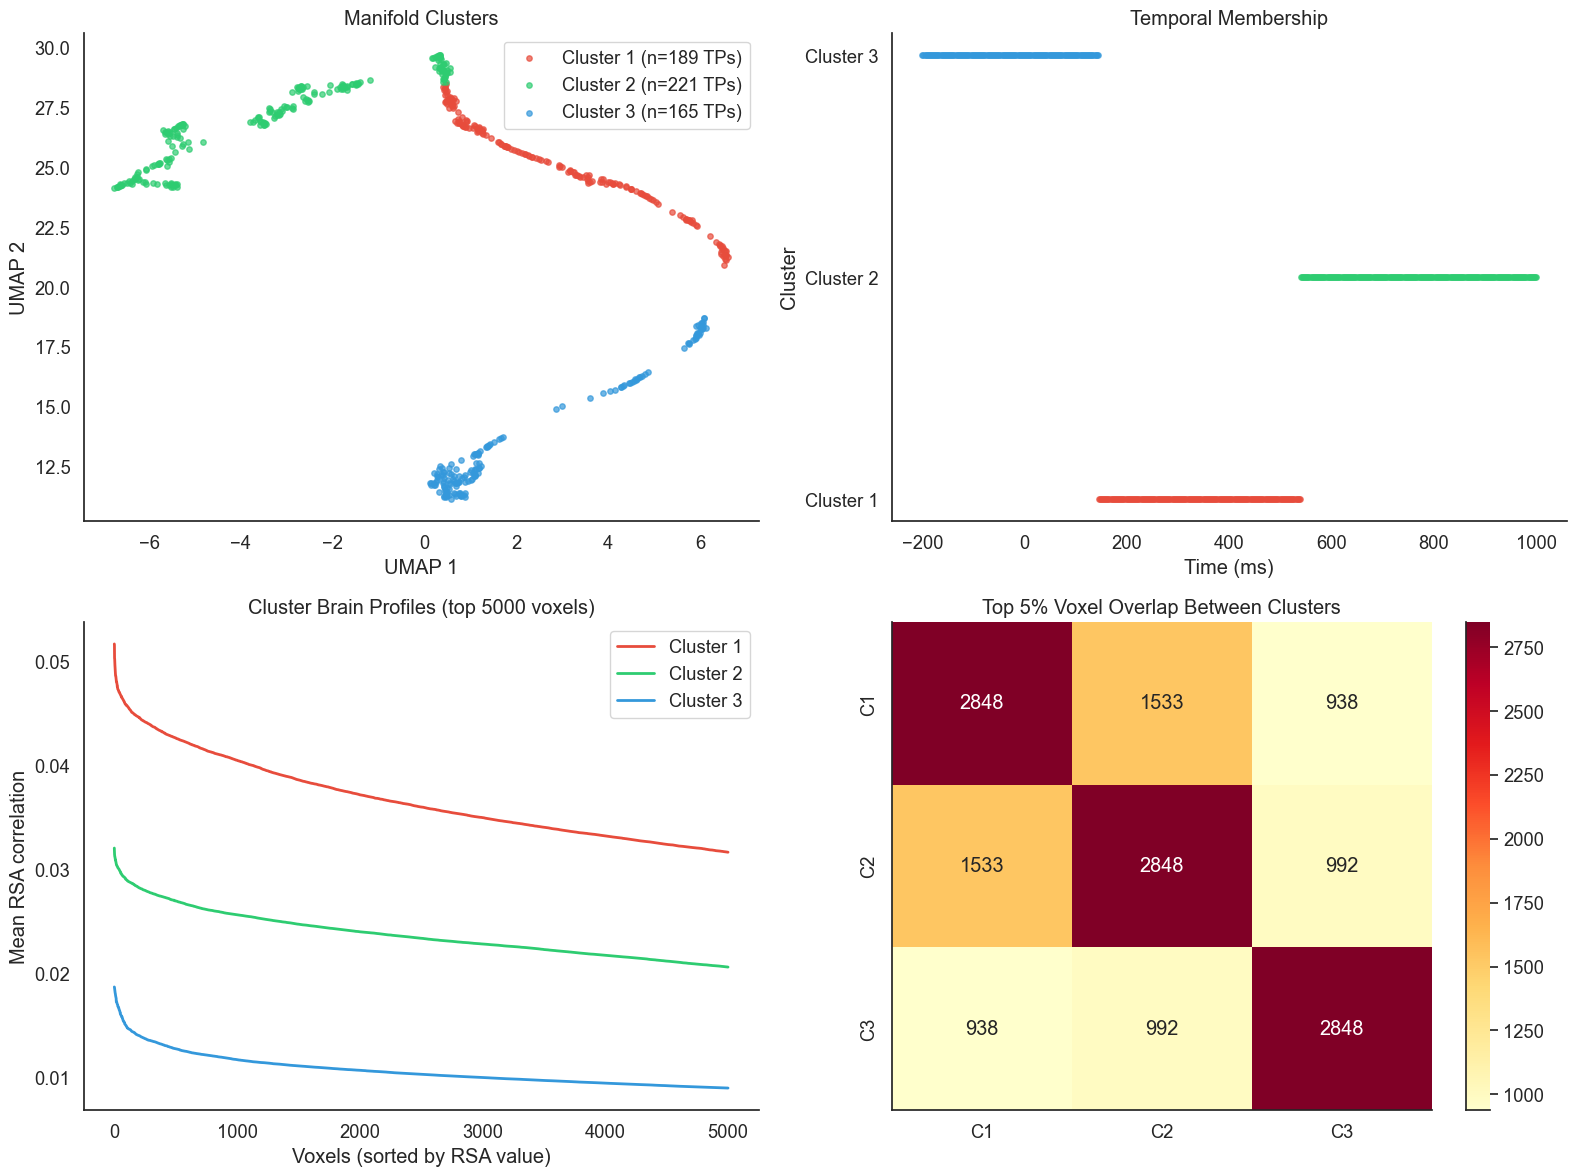

Saved cluster_brain_maps.npy and cluster_labels.npy


In [24]:
# ============================================================
# Cell 17: Three-Cluster Solution — Temporal & Spatial Profiles
# ============================================================
n_clusters = 3  # Force 3 for hypothesis testing (also try best_k)

kmeans_3 = KMeans(n_clusters=n_clusters, n_init=50, random_state=42)
cluster_labels = kmeans_3.fit_predict(emb_3d)

# --- Temporal profile of each cluster ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Manifold with clusters
cluster_colors = ['#e74c3c', '#2ecc71', '#3498db']
for c in range(n_clusters):
    mask_c = cluster_labels == c
    axes[0, 0].scatter(emb_3d[mask_c, 0], emb_3d[mask_c, 1],
                       c=cluster_colors[c], s=15, alpha=0.7,
                       label=f'Cluster {c+1} (n={mask_c.sum()} TPs)')
axes[0, 0].legend()
axes[0, 0].set_xlabel('UMAP 1')
axes[0, 0].set_ylabel('UMAP 2')
axes[0, 0].set_title('Manifold Clusters')

# Plot 2: Which timepoints belong to each cluster
for c in range(n_clusters):
    mask_c = cluster_labels == c
    axes[0, 1].scatter(times[mask_c], np.ones(mask_c.sum()) * c,
                       c=cluster_colors[c], s=15, alpha=0.7)
axes[0, 1].set_xlabel('Time (ms)')
axes[0, 1].set_ylabel('Cluster')
axes[0, 1].set_yticks(range(n_clusters))
axes[0, 1].set_yticklabels([f'Cluster {c+1}' for c in range(n_clusters)])
axes[0, 1].set_title('Temporal Membership')

# Plot 3: Mean brain map for each cluster
cluster_brain_maps = np.zeros((n_clusters, n_voxels))
for c in range(n_clusters):
    mask_c = cluster_labels == c
    cluster_brain_maps[c] = group_data[mask_c].mean(axis=0)

# Show as sorted voxel profiles (rough visualization)
for c in range(n_clusters):
    sorted_vals = np.sort(cluster_brain_maps[c])[::-1]
    axes[1, 0].plot(sorted_vals[:5000], color=cluster_colors[c],
                    linewidth=2, label=f'Cluster {c+1}')
axes[1, 0].set_xlabel('Voxels (sorted by RSA value)')
axes[1, 0].set_ylabel('Mean RSA correlation')
axes[1, 0].set_title('Cluster Brain Profiles (top 5000 voxels)')
axes[1, 0].legend()

# Plot 4: Spatial overlap between clusters
# Top 5% voxels per cluster
top_pct = 95
top_masks = []
for c in range(n_clusters):
    thresh = np.percentile(cluster_brain_maps[c], top_pct)
    top_masks.append(cluster_brain_maps[c] >= thresh)

overlap_matrix = np.zeros((n_clusters, n_clusters))
for i in range(n_clusters):
    for j in range(n_clusters):
        if i == j:
            overlap_matrix[i, j] = top_masks[i].sum()
        else:
            overlap_matrix[i, j] = (top_masks[i] & top_masks[j]).sum()

sns.heatmap(overlap_matrix, annot=True, fmt='.0f',
            xticklabels=[f'C{c+1}' for c in range(n_clusters)],
            yticklabels=[f'C{c+1}' for c in range(n_clusters)],
            cmap='YlOrRd', ax=axes[1, 1])
axes[1, 1].set_title(f'Top {100-top_pct}% Voxel Overlap Between Clusters')

sns.despine()
plt.tight_layout()
plt.show()

# Save cluster brain maps for visualization in your preferred viewer
np.save('cluster_brain_maps.npy', cluster_brain_maps)
np.save('cluster_labels.npy', cluster_labels)
print("Saved cluster_brain_maps.npy and cluster_labels.npy")

In [ ]:
# ============================================================
# Cell 18: Reconstruct Cluster Maps to Nifti (if mask available)
# ============================================================
# ---- Uncomment and edit ----
# mask_img = nib.load('brain_mask.nii.gz')
# mask_data = mask_img.get_fdata().astype(bool)
#
# pathway_names = ['pathway_1', 'pathway_2', 'pathway_3']
# for c in range(n_clusters):
#     vol = np.zeros(mask_data.shape)
#     vol[mask_data] = cluster_brain_maps[c]
#     fname = f'{pathway_names[c]}_brainmap.nii.gz'
#     nib.save(nib.Nifti1Image(vol, mask_img.affine), fname)
#     print(f"Saved {fname}")
#
# # Also save a single volume with cluster labels for each voxel
# # (which cluster has the highest loading at each voxel)
# dominant_cluster = np.argmax(cluster_brain_maps, axis=0) + 1  # 1-indexed
# vol = np.zeros(mask_data.shape)
# vol[mask_data] = dominant_cluster
# nib.save(nib.Nifti1Image(vol, mask_img.affine), 'dominant_pathway_map.nii.gz')
# print("Saved dominant_pathway_map.nii.gz")

print("Uncomment this cell once you have your brain mask loaded.")

---
## Part 7: Subject-Level Robustness

Critical for any claim: does the manifold structure replicate across individual subjects?

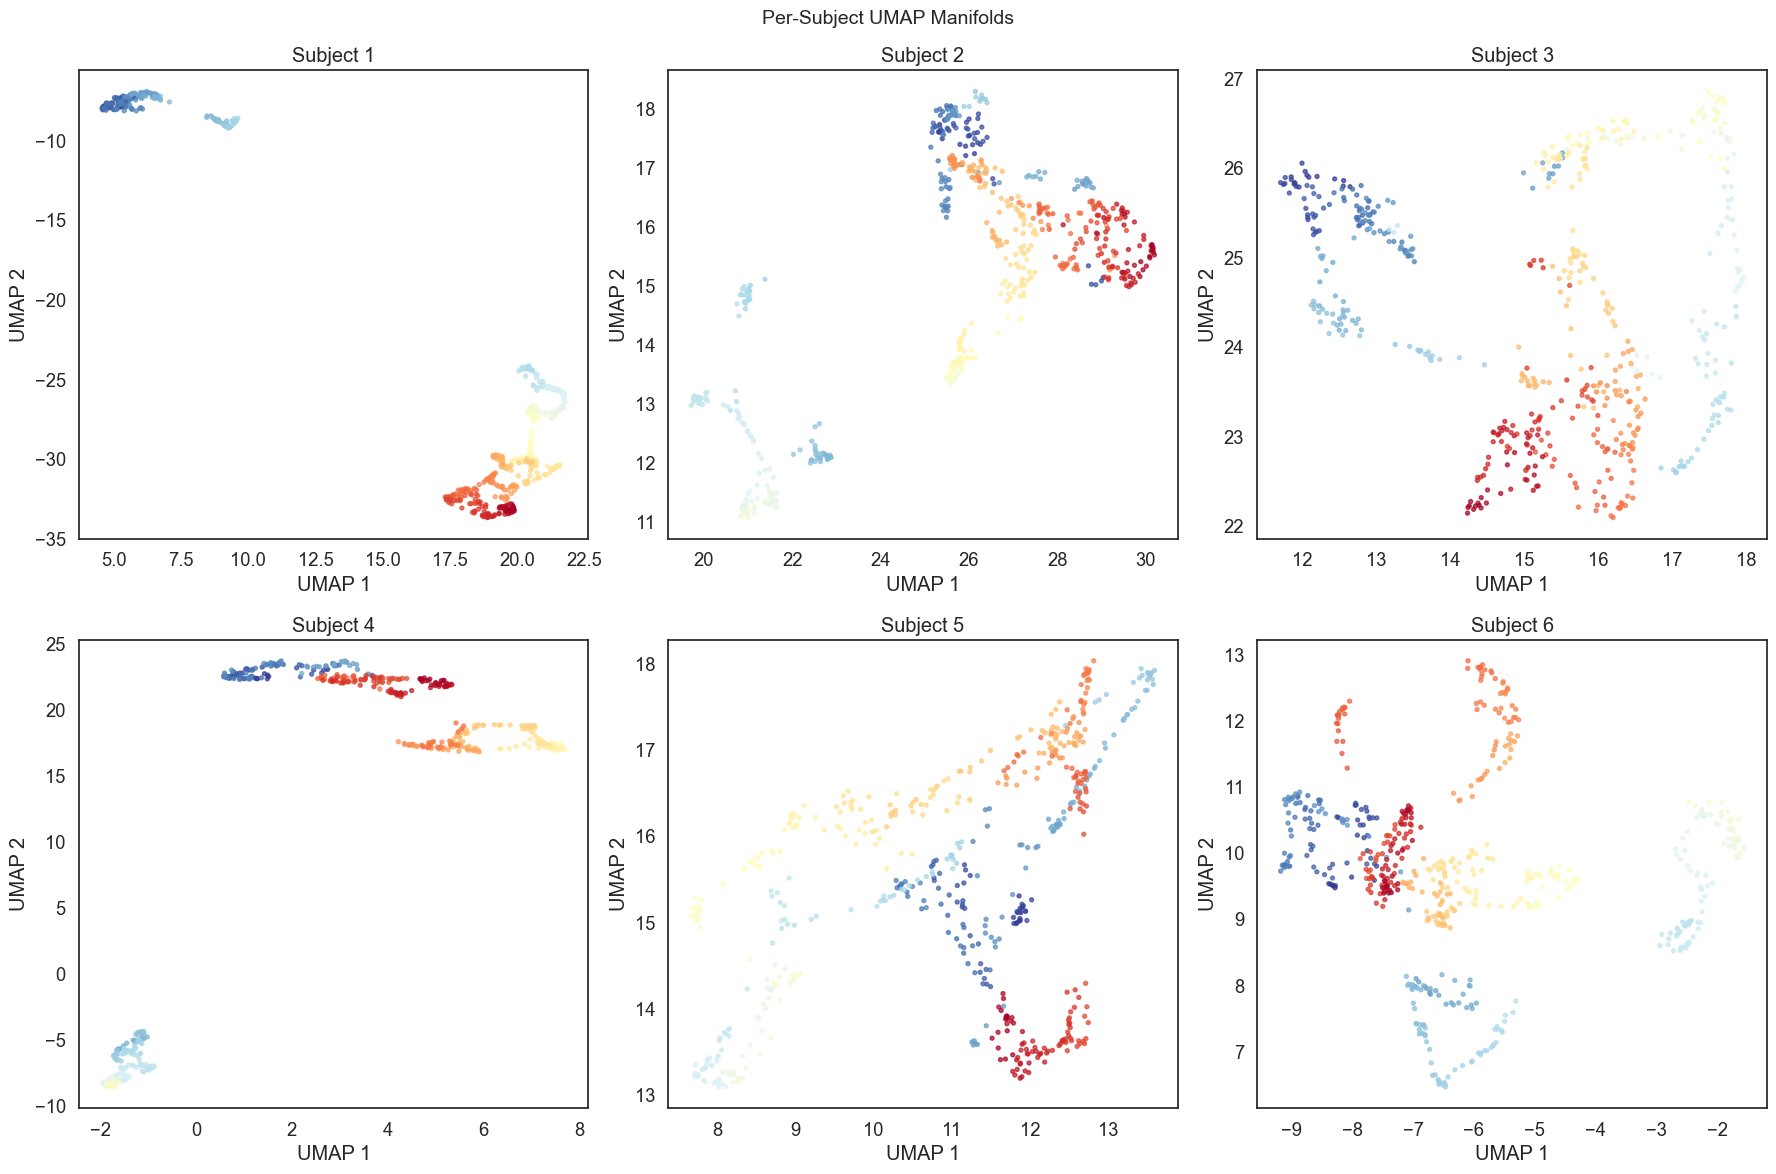

Look for consistent structure across subjects.
Note: UMAP embeddings aren't aligned, so look for similar topology, not exact match.


In [25]:
# ============================================================
# Cell 19: Per-Subject Manifold Embeddings
# ============================================================
n_show = min(n_subjects, 6)  # show first 6 subjects

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

subject_embeddings = []
for s in range(n_show):
    subj_data = rsa_clean[s]  # (575, 56949)
    subj_scaled = StandardScaler().fit_transform(subj_data)
    
    reducer = umap.UMAP(n_components=3, n_neighbors=15, min_dist=0.1,
                        random_state=42)
    emb_s = reducer.fit_transform(subj_scaled)
    subject_embeddings.append(emb_s)
    
    axes[s].scatter(emb_s[:, 0], emb_s[:, 1], c=times, cmap='RdYlBu_r',
                    s=8, alpha=0.7)
    axes[s].set_title(f'Subject {s+1}')
    axes[s].set_xlabel('UMAP 1')
    axes[s].set_ylabel('UMAP 2')

fig.suptitle('Per-Subject UMAP Manifolds', fontsize=14)
plt.tight_layout()
plt.show()

print("Look for consistent structure across subjects.")
print("Note: UMAP embeddings aren't aligned, so look for similar topology, not exact match.")

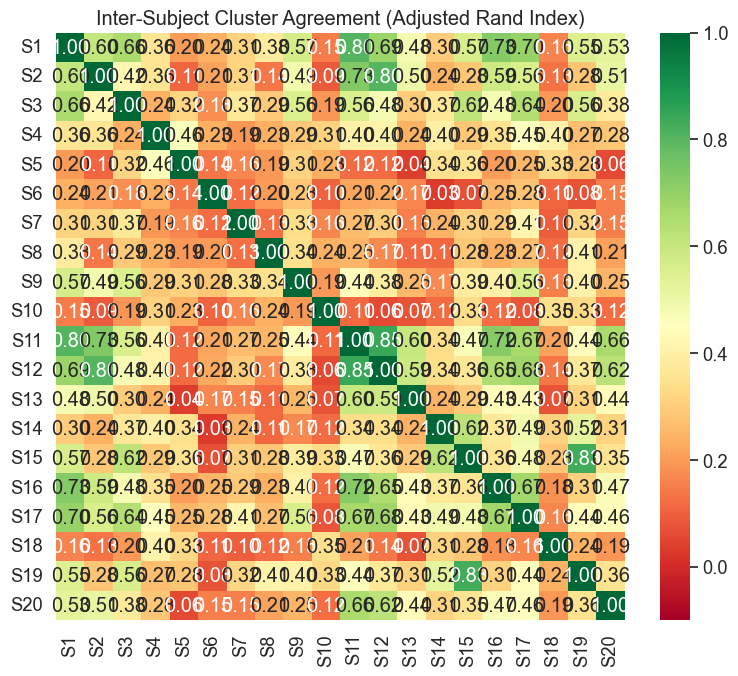


Mean pairwise ARI: 0.3341 ± 0.1821
Range: [0.0299, 0.8450]

→ ARI > 0.3 suggests moderate consistency
→ ARI > 0.5 suggests strong consistency


In [26]:
# ============================================================
# Cell 20: Subject-Level Cluster Consistency
# ============================================================
# For each subject: cluster on manifold, check temporal membership
# Question: do the same timepoints cluster together across subjects?

all_cluster_labels = np.zeros((n_subjects, n_timepoints))

for s in range(n_subjects):
    subj_data = rsa_clean[s]
    subj_scaled = StandardScaler().fit_transform(subj_data)
    
    reducer = umap.UMAP(n_components=3, n_neighbors=15, min_dist=0.1,
                        random_state=42)
    emb_s = reducer.fit_transform(subj_scaled)
    
    kmeans_s = KMeans(n_clusters=3, n_init=20, random_state=42)
    all_cluster_labels[s] = kmeans_s.fit_predict(emb_s)

# Compute pairwise agreement using adjusted Rand index
from sklearn.metrics import adjusted_rand_score

ari_matrix = np.zeros((n_subjects, n_subjects))
for i in range(n_subjects):
    for j in range(n_subjects):
        ari_matrix[i, j] = adjusted_rand_score(
            all_cluster_labels[i].astype(int),
            all_cluster_labels[j].astype(int)
        )

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(ari_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-0.1, vmax=1.0, ax=ax,
            xticklabels=[f'S{s+1}' for s in range(n_subjects)],
            yticklabels=[f'S{s+1}' for s in range(n_subjects)])
ax.set_title('Inter-Subject Cluster Agreement (Adjusted Rand Index)')
plt.tight_layout()
plt.show()

# Report mean ARI (excluding diagonal)
upper_tri = ari_matrix[np.triu_indices(n_subjects, k=1)]
print(f"\nMean pairwise ARI: {upper_tri.mean():.4f} ± {upper_tri.std():.4f}")
print(f"Range: [{upper_tri.min():.4f}, {upper_tri.max():.4f}]")
print("\n→ ARI > 0.3 suggests moderate consistency")
print("→ ARI > 0.5 suggests strong consistency")

---
## Part 8: Temporal Dynamics — When Do Pathways Diverge?

This examines the velocity and curvature of the manifold trajectory to identify transition points where pathways may diverge.

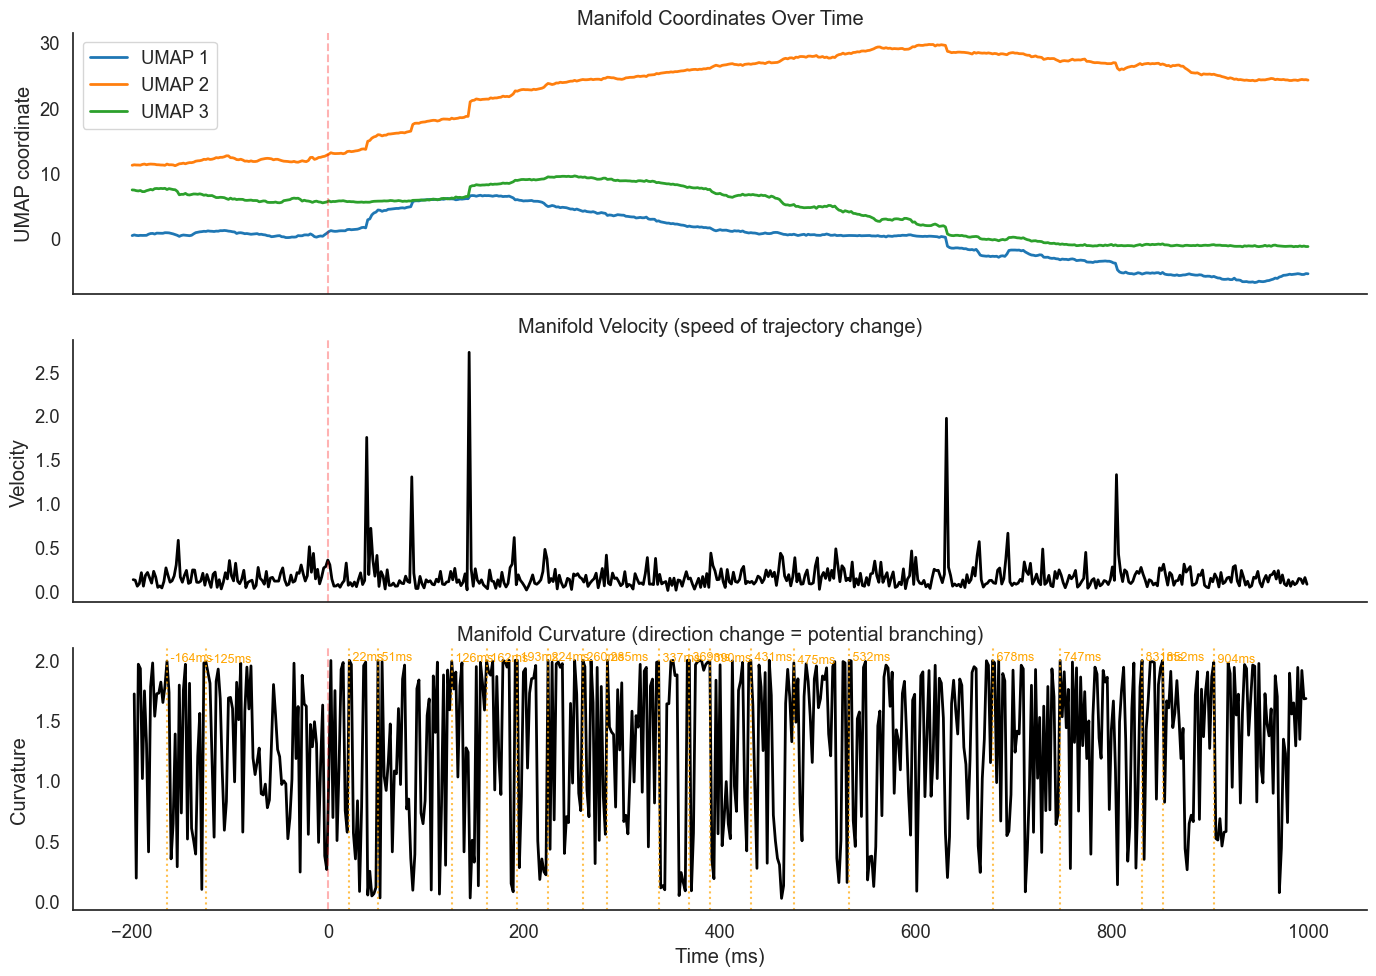


High-curvature timepoints (potential pathway branching):
  -164.5 ms (curvature = 1.9908)
  -124.7 ms (curvature = 1.9862)
  21.6 ms (curvature = 1.9994)
  50.9 ms (curvature = 1.9975)
  126.1 ms (curvature = 1.9899)
  161.7 ms (curvature = 1.9953)
  193.0 ms (curvature = 1.9990)
  224.4 ms (curvature = 1.9978)
  259.9 ms (curvature = 1.9984)
  285.0 ms (curvature = 1.9976)
  337.3 ms (curvature = 1.9881)
  368.6 ms (curvature = 1.9996)
  389.5 ms (curvature = 1.9900)
  431.4 ms (curvature = 1.9991)
  475.3 ms (curvature = 1.9781)
  531.7 ms (curvature = 1.9992)
  678.0 ms (curvature = 1.9961)
  747.0 ms (curvature = 1.9975)
  830.7 ms (curvature = 1.9980)
  851.6 ms (curvature = 1.9959)
  903.8 ms (curvature = 1.9815)


In [28]:
# ============================================================
# Cell 21: Manifold Velocity and Curvature
# ============================================================
emb = embeddings['No PCA (all 56949)']

# Velocity: rate of change along manifold
velocity = np.sqrt(np.sum(np.diff(emb, axis=0)**2, axis=1))
velocity_times = times[:-1] + np.diff(times)[0] / 2  # midpoints

# Curvature: change in direction (approximation)
tangent = np.diff(emb, axis=0)
tangent_norm = tangent / (np.linalg.norm(tangent, axis=1, keepdims=True) + 1e-10)
curvature = np.sqrt(np.sum(np.diff(tangent_norm, axis=0)**2, axis=1))
curvature_times = times[1:-1]

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Individual UMAP dimensions over time
for dim in range(3):
    axes[0].plot(times, emb[:, dim], linewidth=2, label=f'UMAP {dim+1}')
axes[0].legend()
axes[0].set_ylabel('UMAP coordinate')
axes[0].set_title('Manifold Coordinates Over Time')
axes[0].axvline(0, color='red', linestyle='--', alpha=0.3)

# Velocity
axes[1].plot(velocity_times, velocity, 'k-', linewidth=2)
axes[1].set_ylabel('Velocity')
axes[1].set_title('Manifold Velocity (speed of trajectory change)')
axes[1].axvline(0, color='red', linestyle='--', alpha=0.3)

# Curvature
axes[2].plot(curvature_times, curvature, 'k-', linewidth=2)
axes[2].set_ylabel('Curvature')
axes[2].set_xlabel('Time (ms)')
axes[2].set_title('Manifold Curvature (direction change = potential branching)')
axes[2].axvline(0, color='red', linestyle='--', alpha=0.3)

# Mark high-curvature peaks (potential branching points)
from scipy.signal import find_peaks
peaks, props = find_peaks(curvature, height=np.percentile(curvature, 90),
                          distance=10)
for p in peaks:
    axes[2].axvline(curvature_times[p], color='orange', linestyle=':', alpha=0.7)
    axes[2].text(curvature_times[p], curvature[p],
                 f' {curvature_times[p]:.0f}ms', fontsize=9, color='orange')

sns.despine()
plt.tight_layout()
plt.show()

print("\nHigh-curvature timepoints (potential pathway branching):")
for p in peaks:
    print(f"  {curvature_times[p]:.1f} ms (curvature = {curvature[p]:.4f})")

---
## Part 9: Diffusion Map Alternative

Diffusion maps are sometimes preferred over UMAP for scientific analysis because they have a cleaner mathematical foundation (eigendecomposition of a diffusion operator) and preserve global geometry better.

Computing diffusion map...
Diffusion map embedding: (575, 5)


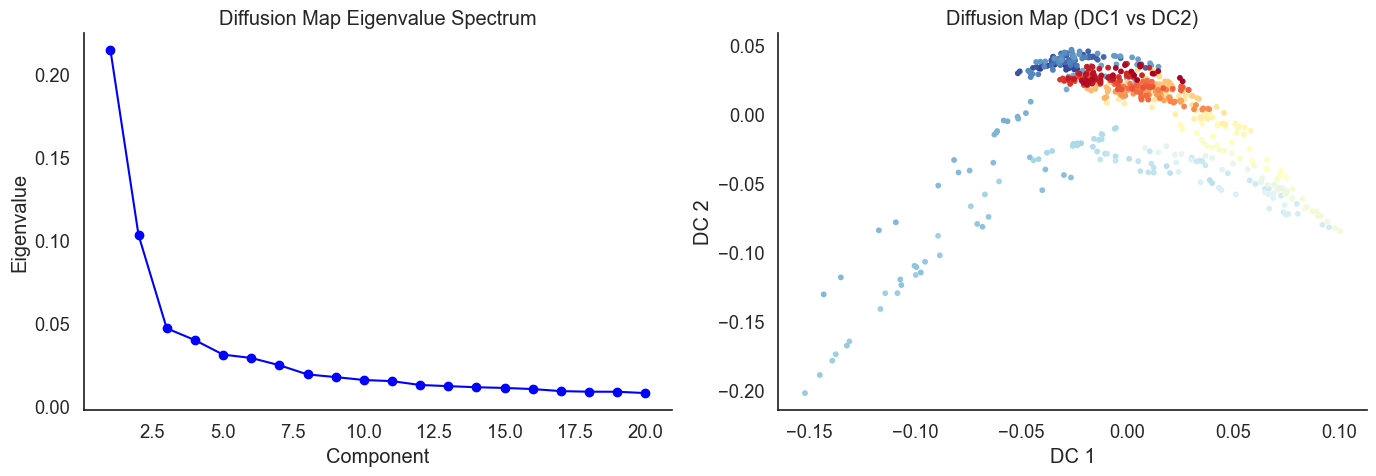

In [29]:
# ============================================================
# Cell 22: Diffusion Map Embedding
# ============================================================
from scipy.spatial.distance import pdist, squareform
from scipy.linalg import eigh

def diffusion_map(X, n_components=3, alpha=1.0, sigma=None):
    """
    Compute diffusion map embedding.
    X: (n_samples, n_features)
    """
    # Pairwise distances
    D = squareform(pdist(X, 'euclidean'))
    
    # Kernel bandwidth
    if sigma is None:
        sigma = np.median(D[D > 0])
    
    # Gaussian kernel
    K = np.exp(-D**2 / (2 * sigma**2))
    
    # Normalize (anisotropic diffusion)
    q = K.sum(axis=1)
    K_alpha = K / np.outer(q**alpha, q**alpha)
    
    # Row-normalize to get transition matrix
    D_inv = np.diag(1.0 / K_alpha.sum(axis=1))
    P = D_inv @ K_alpha
    
    # Eigendecomposition
    eigenvalues, eigenvectors = eigh(P)
    
    # Sort descending
    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    
    # Return components 1 through n_components (skip trivial first)
    embedding = eigenvectors[:, 1:n_components + 1]
    return embedding, eigenvalues

print("Computing diffusion map...")
dm_emb, dm_eigenvalues = diffusion_map(group_scaled, n_components=5)
print(f"Diffusion map embedding: {dm_emb.shape}")

# Eigenvalue spectrum
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, 21), dm_eigenvalues[1:21], 'bo-')
axes[0].set_xlabel('Component')
axes[0].set_ylabel('Eigenvalue')
axes[0].set_title('Diffusion Map Eigenvalue Spectrum')

axes[1].scatter(dm_emb[:, 0], dm_emb[:, 1], c=times, cmap='RdYlBu_r', s=10)
axes[1].set_xlabel('DC 1')
axes[1].set_ylabel('DC 2')
axes[1].set_title('Diffusion Map (DC1 vs DC2)')

sns.despine()
plt.tight_layout()
plt.show()

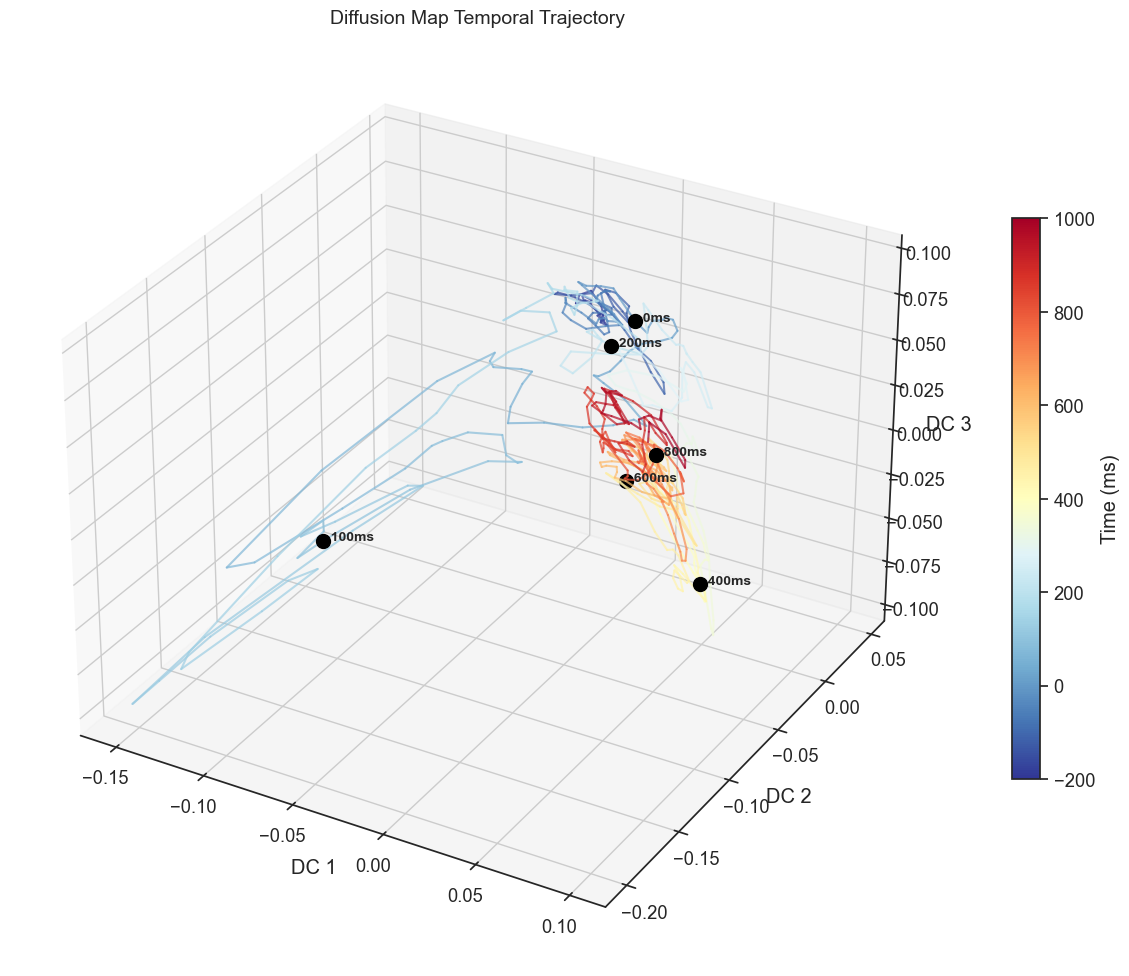

In [30]:
# ============================================================
# Cell 23: 3D Diffusion Map Trajectory
# ============================================================
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

norm = Normalize(vmin=times.min(), vmax=times.max())
colors = cm.RdYlBu_r(norm(times))

for i in range(len(dm_emb) - 1):
    ax.plot(dm_emb[i:i+2, 0], dm_emb[i:i+2, 1], dm_emb[i:i+2, 2],
            color=colors[i], linewidth=1.5, alpha=0.7)

for t_ms in [0, 100, 200, 400, 600, 800]:
    t_idx = np.argmin(np.abs(times - t_ms))
    ax.scatter(*dm_emb[t_idx, :3], s=100, c='black', marker='o', zorder=5)
    ax.text(dm_emb[t_idx, 0], dm_emb[t_idx, 1], dm_emb[t_idx, 2],
            f'  {t_ms}ms', fontsize=10, fontweight='bold')

ax.set_xlabel('DC 1')
ax.set_ylabel('DC 2')
ax.set_zlabel('DC 3')
ax.set_title('Diffusion Map Temporal Trajectory', fontsize=14)

sm = plt.cm.ScalarMappable(cmap='RdYlBu_r', norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Time (ms)', shrink=0.6)
plt.tight_layout()
plt.show()

---
## Part 10: Summary Statistics & Export

Compile key results for reporting.

In [31]:
# ============================================================
# Cell 24: Summary Report
# ============================================================
print("=" * 70)
print("MANIFOLD ANALYSIS SUMMARY")
print("=" * 70)
print(f"\nData: {n_subjects} subjects × {n_timepoints} timepoints × {n_voxels} voxels")
print(f"\n--- Dimensionality ---")
n_90 = np.argmax(cumvar >= 0.9) + 1
n_95 = np.argmax(cumvar >= 0.95) + 1
print(f"  PCA components for 90% var: {n_90}")
print(f"  PCA components for 95% var: {n_95}")
print(f"  Top 3 PCs explain: {cumvar[2]*100:.1f}%")

print(f"\n--- Clustering ---")
print(f"  Best k (silhouette): {best_k}")
print(f"  3-cluster silhouette: {silhouette_score(emb_3d, cluster_labels):.4f}")

print(f"\n--- Subject Consistency ---")
print(f"  Mean pairwise ARI: {upper_tri.mean():.4f} ± {upper_tri.std():.4f}")

print(f"\n--- High-Curvature Timepoints ---")
for p in peaks:
    print(f"  {curvature_times[p]:.1f} ms")

print(f"\n--- Cluster Temporal Ranges ---")
for c in range(n_clusters):
    mask_c = cluster_labels == c
    t_cluster = times[mask_c]
    print(f"  Cluster {c+1}: {t_cluster.min():.0f}–{t_cluster.max():.0f} ms "
          f"(median: {np.median(t_cluster):.0f} ms, n={mask_c.sum()} TPs)")

print("\n" + "=" * 70)
print("\nKey files saved:")
print("  pca_spatial_loadings.npy  — (6, 56949) PCA spatial maps")
print("  pca_temporal_scores.npy   — (575, 6) PCA temporal profiles")
print("  umap_brain_maps.npy       — (3, 56949) UMAP dim → brain correlations")
print("  cluster_brain_maps.npy    — (3, 56949) mean RSA per cluster")
print("  cluster_labels.npy        — (575,) cluster assignment per timepoint")
print("\n→ Load these into your pycortex pipeline to visualize on cortical surface")
print("→ Or reconstruct to nifti using your searchlight mask (see Cell 18)")

MANIFOLD ANALYSIS SUMMARY

Data: 20 subjects × 575 timepoints × 56949 voxels

--- Dimensionality ---
  PCA components for 90% var: 37
  PCA components for 95% var: 61
  Top 3 PCs explain: 53.3%

--- Clustering ---
  Best k (silhouette): 8
  3-cluster silhouette: 0.6005

--- Subject Consistency ---
  Mean pairwise ARI: 0.3341 ± 0.1821

--- High-Curvature Timepoints ---
  -164.5 ms
  -124.7 ms
  21.6 ms
  50.9 ms
  126.1 ms
  161.7 ms
  193.0 ms
  224.4 ms
  259.9 ms
  285.0 ms
  337.3 ms
  368.6 ms
  389.5 ms
  431.4 ms
  475.3 ms
  531.7 ms
  678.0 ms
  747.0 ms
  830.7 ms
  851.6 ms
  903.8 ms

--- Cluster Temporal Ranges ---
  Cluster 1: 145–538 ms (median: 341 ms, n=189 TPs)
  Cluster 2: 540–1000 ms (median: 770 ms, n=221 TPs)
  Cluster 3: -200–143 ms (median: -29 ms, n=165 TPs)


Key files saved:
  pca_spatial_loadings.npy  — (6, 56949) PCA spatial maps
  pca_temporal_scores.npy   — (575, 6) PCA temporal profiles
  umap_brain_maps.npy       — (3, 56949) UMAP dim → brain correlation

In [ ]:
# ============================================================
# Cell 25: Quick Interpretation Guide
# ============================================================
print("""
INTERPRETATION GUIDE
====================

STRONG evidence for three pathways if:
  ✓ Intrinsic dimensionality ≈ 3 (or clearly ≥ 3)
  ✓ Best silhouette at k=3
  ✓ Three PCA/UMAP dimensions map to anatomically distinct regions:
      - Dimension A → ventral temporal (fusiform, IT cortex)
      - Dimension B → dorsal parietal (IPS, SPL)
      - Dimension C → medial (retrosplenial, PHC, PCC, medial temporal)
  ✓ Distinct temporal profiles per cluster
  ✓ Consistent across subjects (ARI > 0.3)
  ✓ Stable across UMAP hyperparameters
  ✓ Consistent between UMAP and diffusion maps

WEAK / ALTERNATIVE interpretations if:
  ✗ Intrinsic dimensionality >> 3 → more than 3 pathways or no clean structure
  ✗ Best silhouette at k=2 → classical two-stream is sufficient
  ✗ Third dimension is noisy / doesn't map to coherent anatomy
  ✗ Low inter-subject consistency → individual differences dominate
  ✗ Structure changes with UMAP hyperparameters → artifact

NEXT STEPS:
  1. Project brain maps onto cortical surface (pycortex)
  2. Compare cluster maps against Kastner atlas ROIs
  3. Test whether the "middle pathway" dimension correlates with
     your valence-arousal model (linking to emotion content)
  4. Statistical inference: permutation tests on cluster structure
""")

In [32]:
# ============================================================
# Spatial Manifold Analysis: Clustering Voxels by Temporal Profile
# ============================================================

# Transpose: each voxel is a sample, each timepoint is a feature
# group_data shape: (575, 56949) → transpose to (56949, 575)
voxel_profiles = group_data.T  # (56949, 575)

print(f"Voxel profiles shape: {voxel_profiles.shape}")
print(f"  Each of {voxel_profiles.shape[0]} voxels described by {voxel_profiles.shape[1]} timepoints")

# Z-score each voxel's temporal profile
voxel_scaled = StandardScaler().fit_transform(voxel_profiles)  # z-score across timepoints per voxel

Voxel profiles shape: (56949, 575)
  Each of 56949 voxels described by 575 timepoints


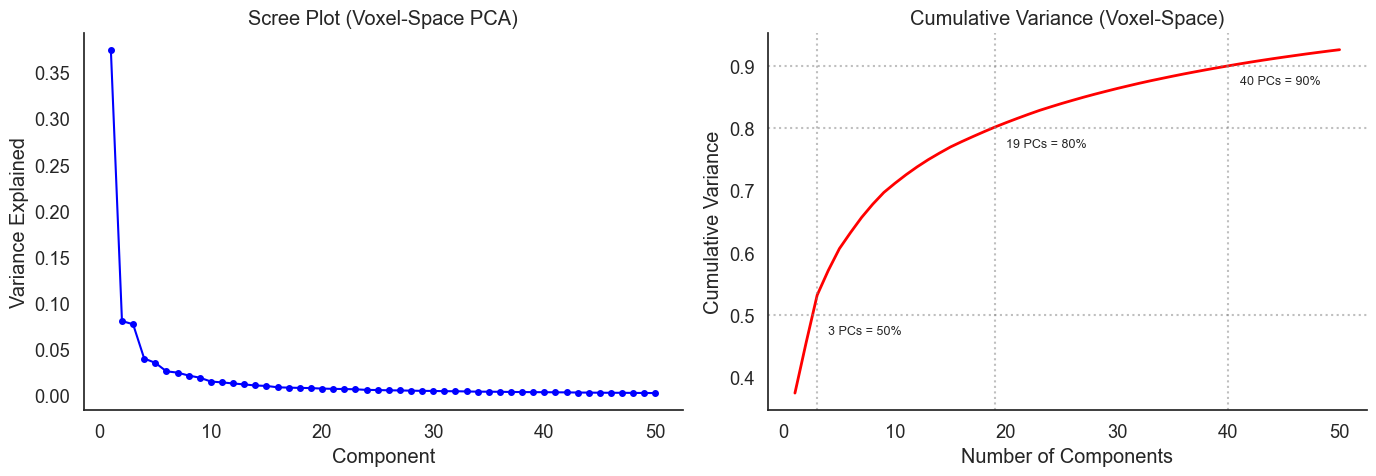


Top 5 PCs explain: 60.7%


In [33]:
# ============================================================
# PCA on Voxel Space — What dimensions organize brain regions?
# ============================================================
pca_voxel = PCA(n_components=50, random_state=42)
voxel_pca = pca_voxel.fit_transform(voxel_scaled)  # (56949, 50)

cumvar_v = np.cumsum(pca_voxel.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, 51), pca_voxel.explained_variance_ratio_, 'bo-', markersize=4)
axes[0].set_xlabel('Component')
axes[0].set_ylabel('Variance Explained')
axes[0].set_title('Scree Plot (Voxel-Space PCA)')

axes[1].plot(range(1, 51), cumvar_v, 'r-', linewidth=2)
for thresh in [0.5, 0.8, 0.9]:
    n_comp = np.argmax(cumvar_v >= thresh) + 1
    axes[1].axhline(thresh, color='gray', linestyle=':', alpha=0.5)
    axes[1].axvline(n_comp, color='gray', linestyle=':', alpha=0.5)
    axes[1].text(n_comp + 1, thresh - 0.03, f'{n_comp} PCs = {thresh*100:.0f}%', fontsize=9)

axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance')
axes[1].set_title('Cumulative Variance (Voxel-Space)')

sns.despine()
plt.tight_layout()
plt.show()

print(f"\nTop 5 PCs explain: {cumvar_v[4]*100:.1f}%")

In [34]:
# ============================================================
# UMAP on Voxel Space — Embed 56949 voxels into low-D
# ============================================================
# This embeds each voxel based on its temporal RSA profile
# Voxels with similar temporal dynamics will be nearby

print("Running UMAP on voxel space (56949 voxels × 575 timepoints)...")
print("This may take a few minutes...")

reducer_voxel = umap.UMAP(
    n_components=3, 
    n_neighbors=30,      # larger neighborhood for smoother structure
    min_dist=0.05,
    metric='correlation', # correlation distance — groups voxels with similar temporal shape
    random_state=42
)
voxel_emb = reducer_voxel.fit_transform(voxel_scaled)  # (56949, 3)

print(f"Voxel embedding shape: {voxel_emb.shape}")

Running UMAP on voxel space (56949 voxels × 575 timepoints)...
This may take a few minutes...
Voxel embedding shape: (56949, 3)


  k=2: silhouette = 0.4227
  k=3: silhouette = 0.3115
  k=4: silhouette = 0.3343
  k=5: silhouette = 0.3145
  k=6: silhouette = 0.3074


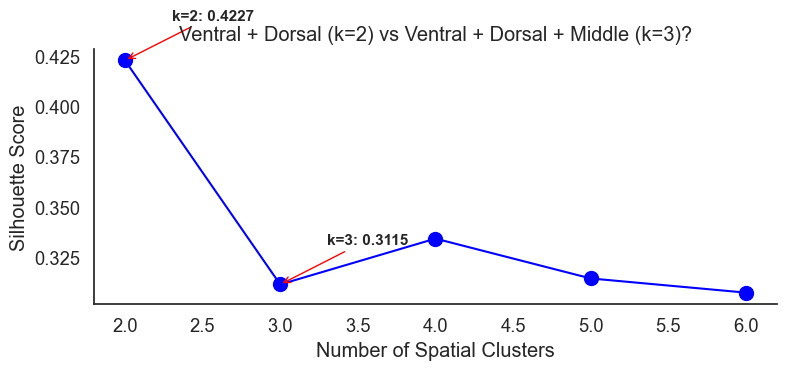

In [35]:
# ============================================================
# Key Test: 2 vs 3 Spatial Clusters
# ============================================================
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.metrics import silhouette_score

# Test k=2 through k=6
k_range = range(2, 7)
results = {}

for k in k_range:
    kmeans = KMeans(n_clusters=k, n_init=30, random_state=42)
    labels = kmeans.fit_predict(voxel_emb)
    sil = silhouette_score(voxel_emb, labels, sample_size=10000, random_state=42)
    results[k] = {'labels': labels, 'silhouette': sil}
    print(f"  k={k}: silhouette = {sil:.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(k_range), [results[k]['silhouette'] for k in k_range], 'bo-', markersize=10)
ax.set_xlabel('Number of Spatial Clusters')
ax.set_ylabel('Silhouette Score')
ax.set_title('Ventral + Dorsal (k=2) vs Ventral + Dorsal + Middle (k=3)?')

# Highlight k=2 and k=3
for k in [2, 3]:
    ax.annotate(f'k={k}: {results[k]["silhouette"]:.4f}',
                xy=(k, results[k]['silhouette']),
                xytext=(k + 0.3, results[k]['silhouette'] + 0.02),
                fontsize=11, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='red'))

sns.despine()
plt.tight_layout()
plt.show()

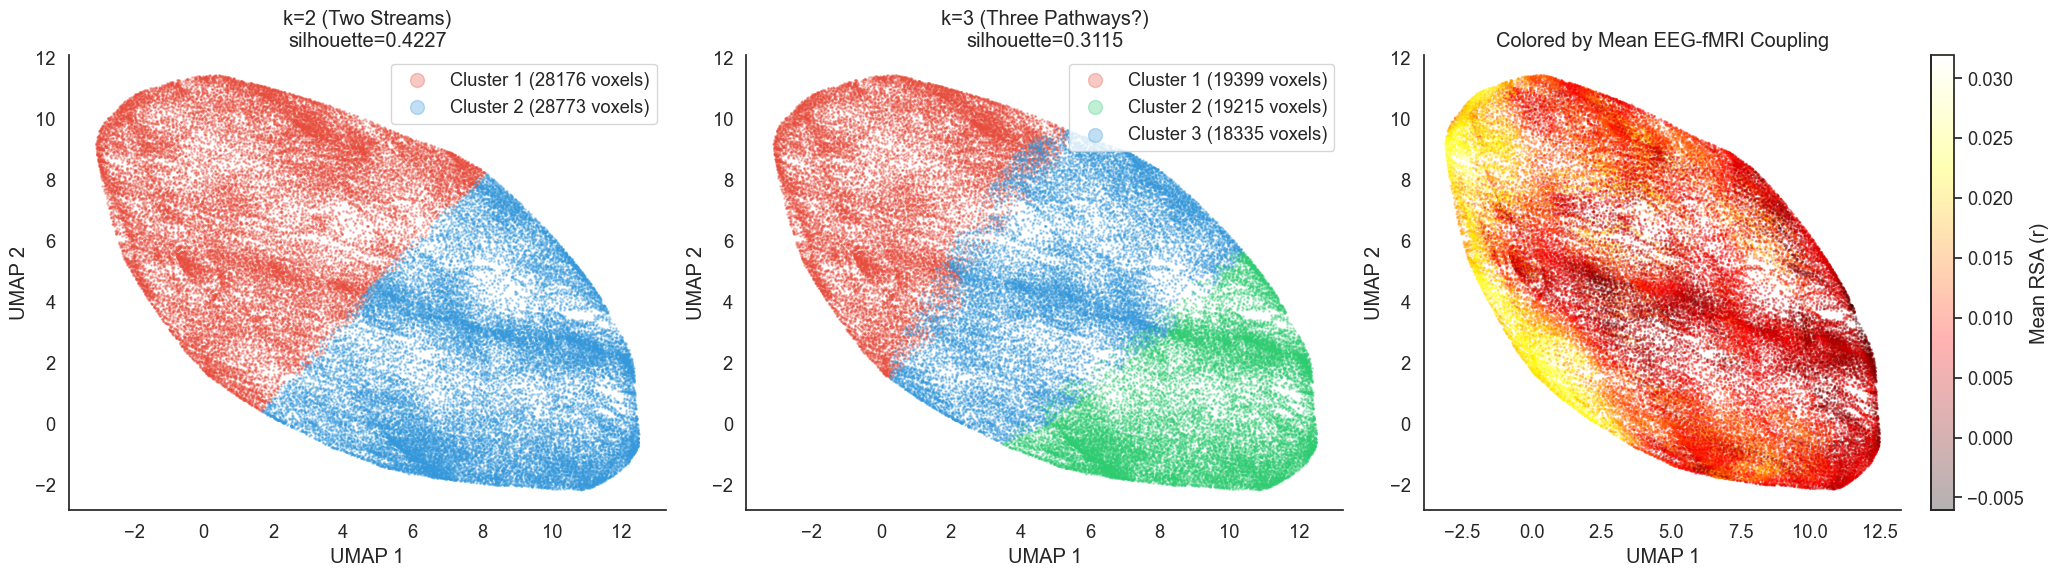

In [36]:
# ============================================================
# Visualize Spatial Clusters in UMAP Space
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# k=2: Classical two-stream
labels_2 = results[2]['labels']
cluster_colors_2 = ['#e74c3c', '#3498db']
for c in range(2):
    mask = labels_2 == c
    axes[0].scatter(voxel_emb[mask, 0], voxel_emb[mask, 1],
                    c=cluster_colors_2[c], s=1, alpha=0.3,
                    label=f'Cluster {c+1} ({mask.sum()} voxels)')
axes[0].legend(markerscale=10)
axes[0].set_title(f'k=2 (Two Streams)\nsilhouette={results[2]["silhouette"]:.4f}')
axes[0].set_xlabel('UMAP 1')
axes[0].set_ylabel('UMAP 2')

# k=3: Three pathways
labels_3 = results[3]['labels']
cluster_colors_3 = ['#e74c3c', '#2ecc71', '#3498db']
for c in range(3):
    mask = labels_3 == c
    axes[1].scatter(voxel_emb[mask, 0], voxel_emb[mask, 1],
                    c=cluster_colors_3[c], s=1, alpha=0.3,
                    label=f'Cluster {c+1} ({mask.sum()} voxels)')
axes[1].legend(markerscale=10)
axes[1].set_title(f'k=3 (Three Pathways?)\nsilhouette={results[3]["silhouette"]:.4f}')
axes[1].set_xlabel('UMAP 1')
axes[1].set_ylabel('UMAP 2')

# k=3 colored by mean RSA value (to see which clusters have stronger coupling)
mean_rsa = group_data.mean(axis=0)  # mean across time per voxel
sc = axes[2].scatter(voxel_emb[:, 0], voxel_emb[:, 1],
                     c=mean_rsa, cmap='hot', s=1, alpha=0.3)
plt.colorbar(sc, ax=axes[2], label='Mean RSA (r)')
axes[2].set_title('Colored by Mean EEG-fMRI Coupling')
axes[2].set_xlabel('UMAP 1')
axes[2].set_ylabel('UMAP 2')

sns.despine()
plt.tight_layout()
plt.show()

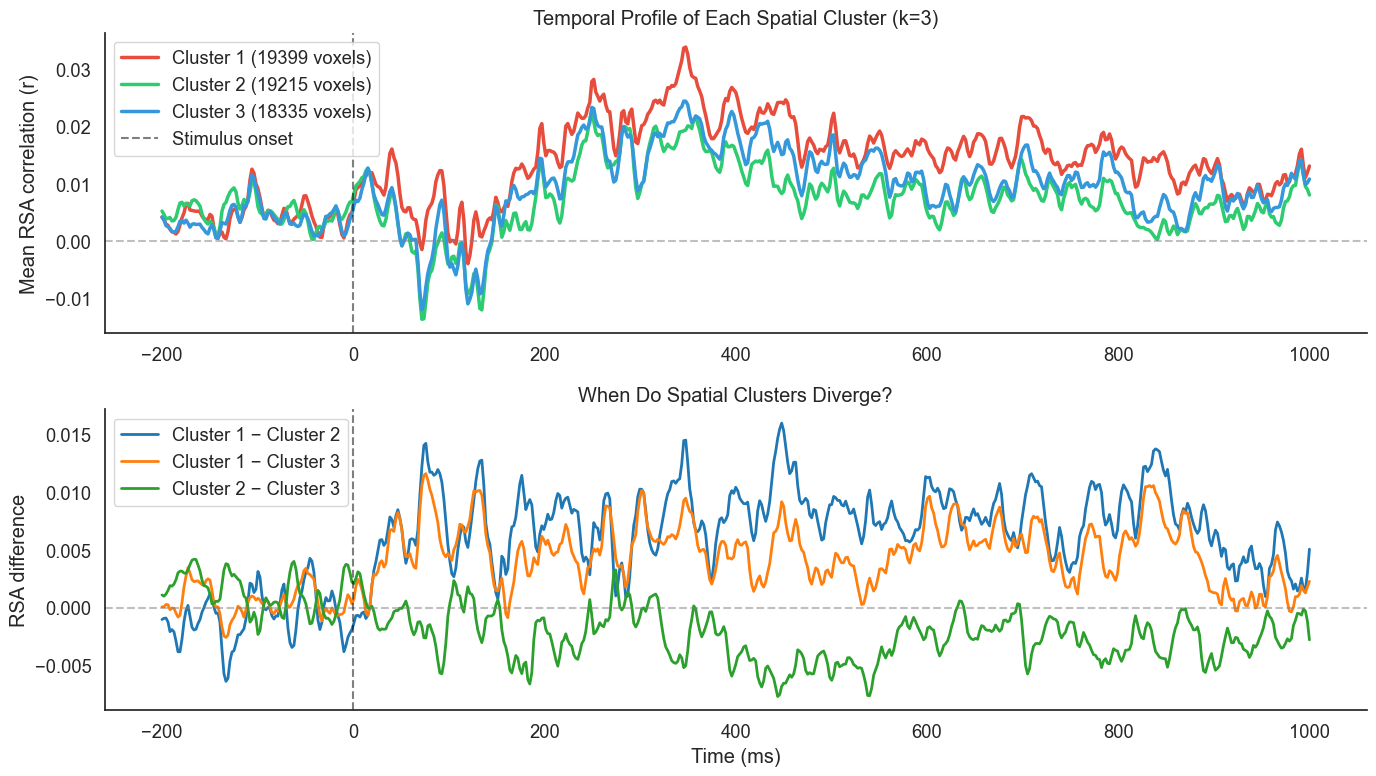

In [37]:
# ============================================================
# Temporal Profiles of Spatial Clusters (k=3)
# ============================================================
# For each spatial cluster, what is the average temporal RSA profile?
# This tells you WHEN each brain network is engaged

labels_3 = results[3]['labels']

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Individual cluster profiles
for c in range(3):
    mask = labels_3 == c
    cluster_timecourse = group_data[:, mask].mean(axis=1)  # mean across voxels in cluster
    cluster_sem = group_data[:, mask].std(axis=1) / np.sqrt(mask.sum())
    
    axes[0].plot(times, cluster_timecourse, linewidth=2.5, color=cluster_colors_3[c],
                 label=f'Cluster {c+1} ({mask.sum()} voxels)')
    axes[0].fill_between(times, cluster_timecourse - cluster_sem,
                         cluster_timecourse + cluster_sem,
                         color=cluster_colors_3[c], alpha=0.15)

axes[0].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[0].axvline(0, color='black', linestyle='--', alpha=0.5, label='Stimulus onset')
axes[0].legend()
axes[0].set_ylabel('Mean RSA correlation (r)')
axes[0].set_title('Temporal Profile of Each Spatial Cluster (k=3)')

# Difference between clusters — when do they diverge?
for i in range(3):
    for j in range(i + 1, 3):
        mask_i = labels_3 == i
        mask_j = labels_3 == j
        diff = group_data[:, mask_i].mean(axis=1) - group_data[:, mask_j].mean(axis=1)
        axes[1].plot(times, diff, linewidth=2,
                     label=f'Cluster {i+1} − Cluster {j+1}')

axes[1].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].axvline(0, color='black', linestyle='--', alpha=0.5)
axes[1].legend()
axes[1].set_xlabel('Time (ms)')
axes[1].set_ylabel('RSA difference')
axes[1].set_title('When Do Spatial Clusters Diverge?')

sns.despine()
plt.tight_layout()
plt.show()

In [38]:
# ============================================================
# Save Spatial Cluster Maps for Brain Visualization
# ============================================================
# Each voxel gets a cluster label — project back to brain

# Save as searchlight-space vectors
np.save('spatial_cluster_labels_k2.npy', results[2]['labels'])
np.save('spatial_cluster_labels_k3.npy', results[3]['labels'])
np.save('voxel_umap_embedding.npy', voxel_emb)

print("Saved spatial cluster labels for k=2 and k=3")
print("Each is a (56949,) vector — map back to brain with your searchlight mask")

# ---- Reconstruct to nifti ----
# Uncomment when mask is available:
# mask_img = nib.load('brain_mask.nii.gz')
# mask_data = mask_img.get_fdata().astype(bool)
#
# for k_val in [2, 3]:
#     vol = np.zeros(mask_data.shape)
#     vol[mask_data] = results[k_val]['labels'] + 1  # 1-indexed
#     nib.save(nib.Nifti1Image(vol.astype(np.int16), mask_img.affine),
#              f'spatial_clusters_k{k_val}.nii.gz')
#     print(f"Saved spatial_clusters_k{k_val}.nii.gz")
#
# # Also save the temporal profile of each cluster as a nifti time series
# # (useful for comparing with known functional networks)
# for c in range(3):
#     mask_c = results[3]['labels'] == c
#     vol = np.zeros((*mask_data.shape, n_timepoints))
#     # Mean temporal profile for this cluster's voxels
#     print(f"Cluster {c+1}: {mask_c.sum()} voxels")

Saved spatial cluster labels for k=2 and k=3
Each is a (56949,) vector — map back to brain with your searchlight mask


In [39]:
# ============================================================
# Gradient Analysis: Map UMAP voxel coordinates back to brain
# ============================================================
# Instead of clustering, treat each UMAP dimension as a continuous
# spatial gradient and project it back to brain space

# voxel_emb shape: (56949, 3)
# Each column is a continuous brain map

np.save('voxel_umap_dim1.npy', voxel_emb[:, 0])  # gradient axis 1
np.save('voxel_umap_dim2.npy', voxel_emb[:, 1])  # gradient axis 2
np.save('voxel_umap_dim3.npy', voxel_emb[:, 2])  # gradient axis 3

# Reconstruct to nifti:
# mask_img = nib.load('brain_mask.nii.gz')
# mask_data = mask_img.get_fdata().astype(bool)
# for dim in range(3):
#     vol = np.zeros(mask_data.shape)
#     vol[mask_data] = voxel_emb[:, dim]
#     nib.save(nib.Nifti1Image(vol, mask_img.affine),
#              f'voxel_gradient_dim{dim+1}.nii.gz')

print("Project these 3 gradient maps onto cortical surface")
print("Look for whether the gradients align with ventral/dorsal/medial anatomy")

Project these 3 gradient maps onto cortical surface
Look for whether the gradients align with ventral/dorsal/medial anatomy


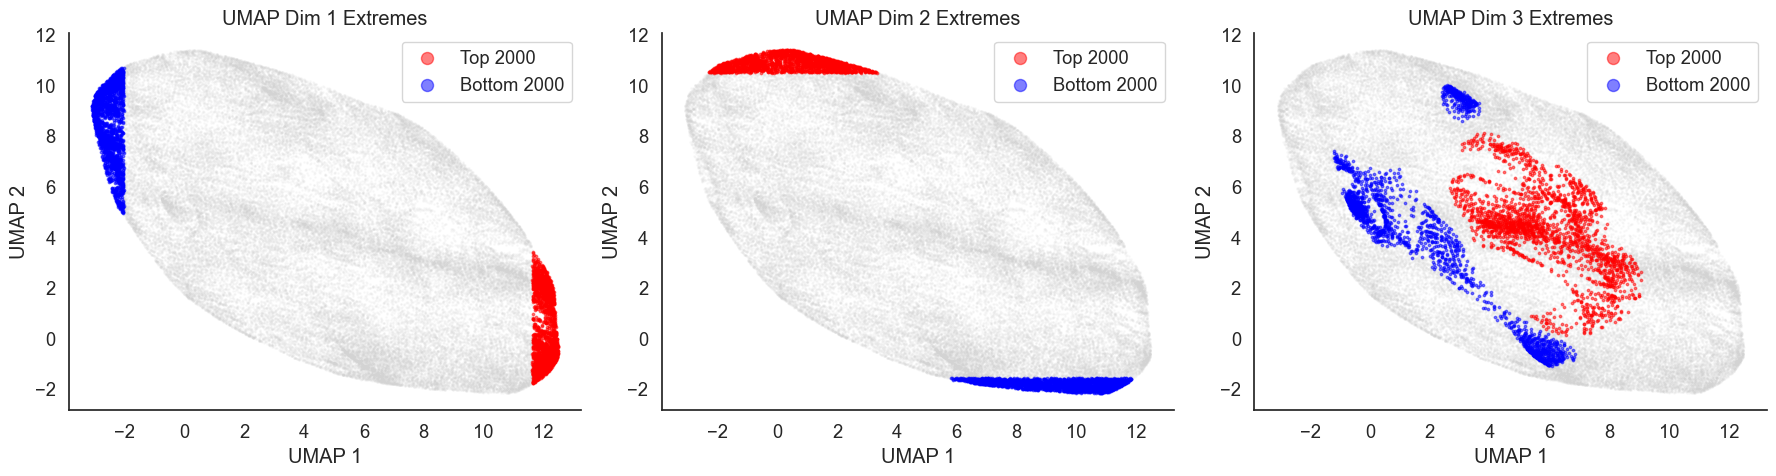

Map these extreme voxel sets onto brain surface
If Dim1 extremes = ventral vs dorsal, Dim2 or Dim3 extremes
might reveal medial structures as a third pole


In [40]:
# ============================================================
# Alternative: Use the extremes of the manifold
# ============================================================
# Instead of clustering the whole cloud, identify voxels at the
# extremes of each UMAP dimension — these are the most distinctive

n_extreme = 2000  # top/bottom voxels per dimension

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for dim in range(3):
    vals = voxel_emb[:, dim]
    
    # Top and bottom extremes
    top_idx = np.argsort(vals)[-n_extreme:]
    bot_idx = np.argsort(vals)[:n_extreme]
    mid_mask = np.ones(len(vals), dtype=bool)
    mid_mask[top_idx] = False
    mid_mask[bot_idx] = False
    
    axes[dim].scatter(voxel_emb[mid_mask, 0], voxel_emb[mid_mask, 1],
                      c='lightgray', s=1, alpha=0.1)
    axes[dim].scatter(voxel_emb[top_idx, 0], voxel_emb[top_idx, 1],
                      c='red', s=3, alpha=0.5, label=f'Top {n_extreme}')
    axes[dim].scatter(voxel_emb[bot_idx, 0], voxel_emb[bot_idx, 1],
                      c='blue', s=3, alpha=0.5, label=f'Bottom {n_extreme}')
    axes[dim].legend(markerscale=5)
    axes[dim].set_title(f'UMAP Dim {dim+1} Extremes')
    axes[dim].set_xlabel('UMAP 1')
    axes[dim].set_ylabel('UMAP 2')

sns.despine()
plt.tight_layout()
plt.show()

# Save extreme voxel indices for brain mapping
for dim in range(3):
    vals = voxel_emb[:, dim]
    top_idx = np.argsort(vals)[-n_extreme:]
    bot_idx = np.argsort(vals)[:n_extreme]
    np.save(f'extreme_voxels_dim{dim+1}_top.npy', top_idx)
    np.save(f'extreme_voxels_dim{dim+1}_bottom.npy', bot_idx)

print("Map these extreme voxel sets onto brain surface")
print("If Dim1 extremes = ventral vs dorsal, Dim2 or Dim3 extremes")
print("might reveal medial structures as a third pole")

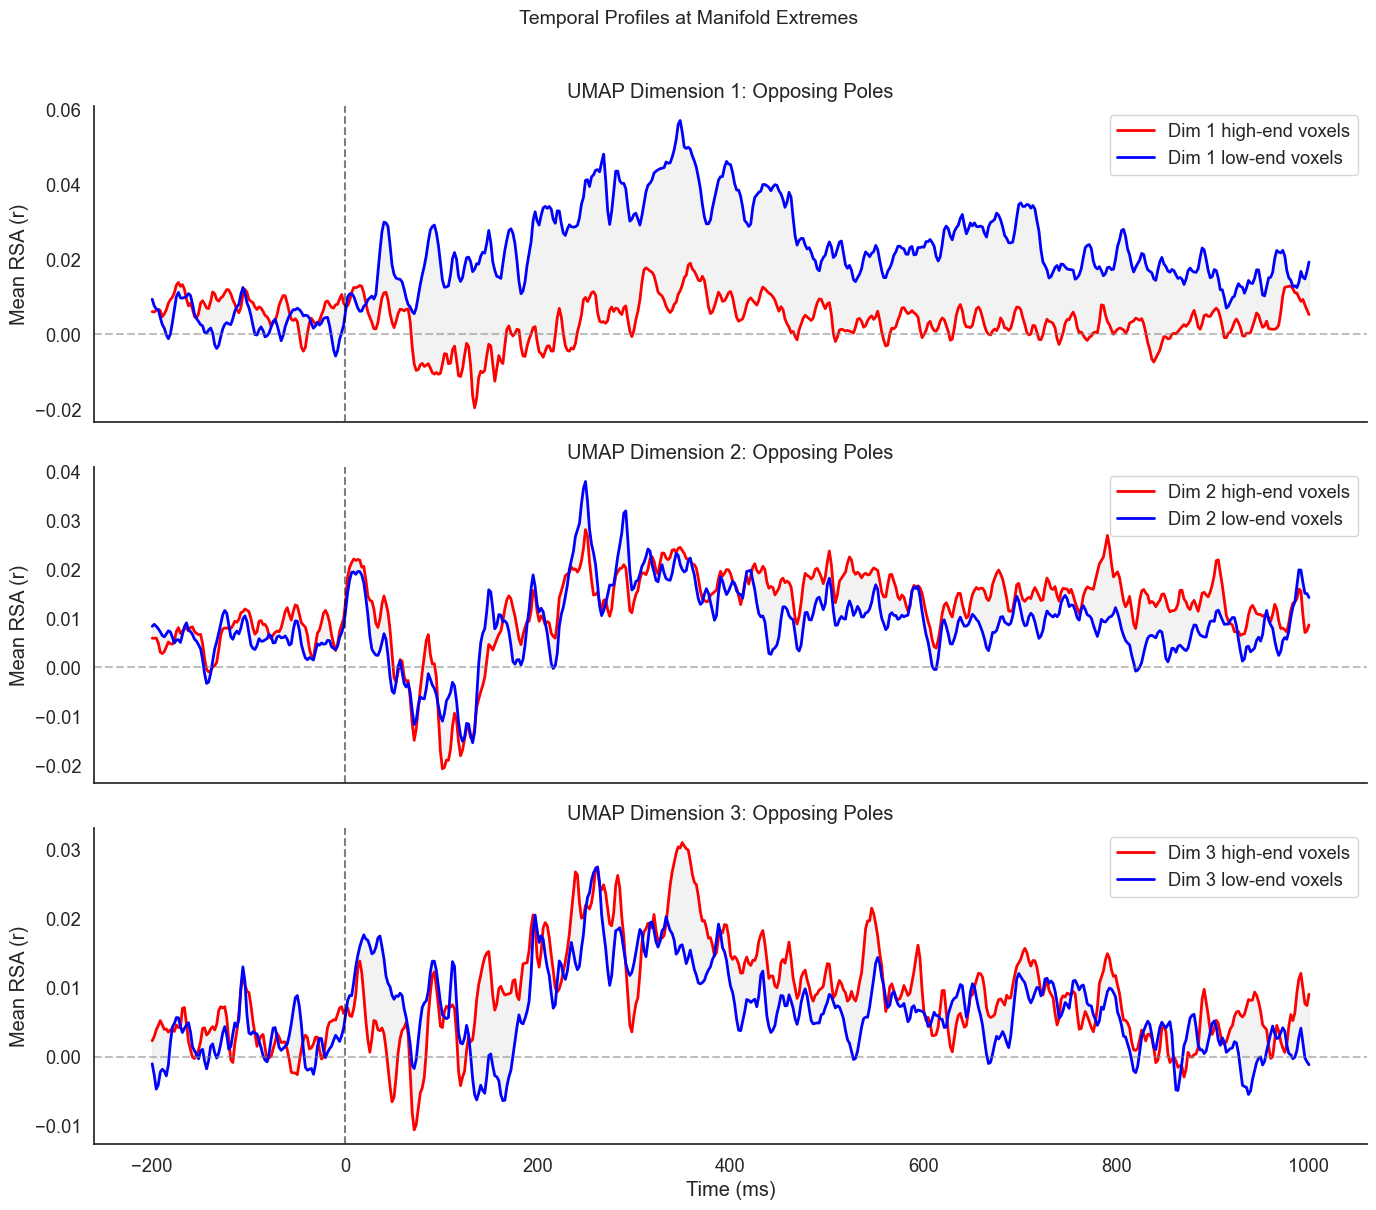

In [41]:
# ============================================================
# Temporal profiles of manifold extremes (more informative than clusters)
# ============================================================
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

for dim in range(3):
    vals = voxel_emb[:, dim]
    top_idx = np.argsort(vals)[-n_extreme:]
    bot_idx = np.argsort(vals)[:n_extreme]
    
    top_profile = group_data[:, top_idx].mean(axis=1)
    bot_profile = group_data[:, bot_idx].mean(axis=1)
    
    axes[dim].plot(times, top_profile, 'r-', linewidth=2,
                   label=f'Dim {dim+1} high-end voxels')
    axes[dim].plot(times, bot_profile, 'b-', linewidth=2,
                   label=f'Dim {dim+1} low-end voxels')
    axes[dim].fill_between(times, top_profile, bot_profile, alpha=0.1, color='gray')
    axes[dim].axhline(0, color='gray', linestyle='--', alpha=0.5)
    axes[dim].axvline(0, color='black', linestyle='--', alpha=0.5)
    axes[dim].legend(loc='upper right')
    axes[dim].set_ylabel('Mean RSA (r)')
    axes[dim].set_title(f'UMAP Dimension {dim+1}: Opposing Poles')

axes[-1].set_xlabel('Time (ms)')
fig.suptitle('Temporal Profiles at Manifold Extremes', fontsize=14, y=1.01)
sns.despine()
plt.tight_layout()
plt.show()